In [2]:
cwe_stats = "../dataset_test/data/"
import os
import pandas as pd
original_df = pd.DataFrame(columns=[
    "cwe",
    'additions',
    'deletions',
])
for file in os.listdir(cwe_stats):
    if file.endswith(".jsonl") and file not in ["NVD-CWE-Other.jsonl"]:
        with open(cwe_stats + "/" + file, "r") as f:
            lines = f.readlines()
            import json
            for line in lines:
                data = json.loads(line)
                cwe = data["cwe"]
                additions = data["additions"]
                deletions = data["deletions"]
                

                # Store the results in a dataframe
                results = pd.DataFrame({
                    "cwe": cwe,
                    'additions': [additions],
                    'deletions': [deletions],
                })
                
                original_df = pd.concat([original_df, results], ignore_index=True)
                

    
                
# Ensure additions and deletions are integers
original_df["additions"] = original_df["additions"].astype(int)
original_df["deletions"] = original_df["deletions"].astype(int)


In [3]:
# Filter out cwe that have less than 20 rows
original_df = original_df.groupby("cwe").filter(lambda x: len(x) >= 20)
original_df

,cwe,additions,deletions
22,CWE-74,6,1
23,CWE-74,6,1
24,CWE-74,1,1
25,CWE-74,1,1
26,CWE-74,8,1
...,...,...,...
1697,CWE-476,3,0
1698,CWE-476,2,0
1699,CWE-476,2,0
1700,CWE-476,34,33


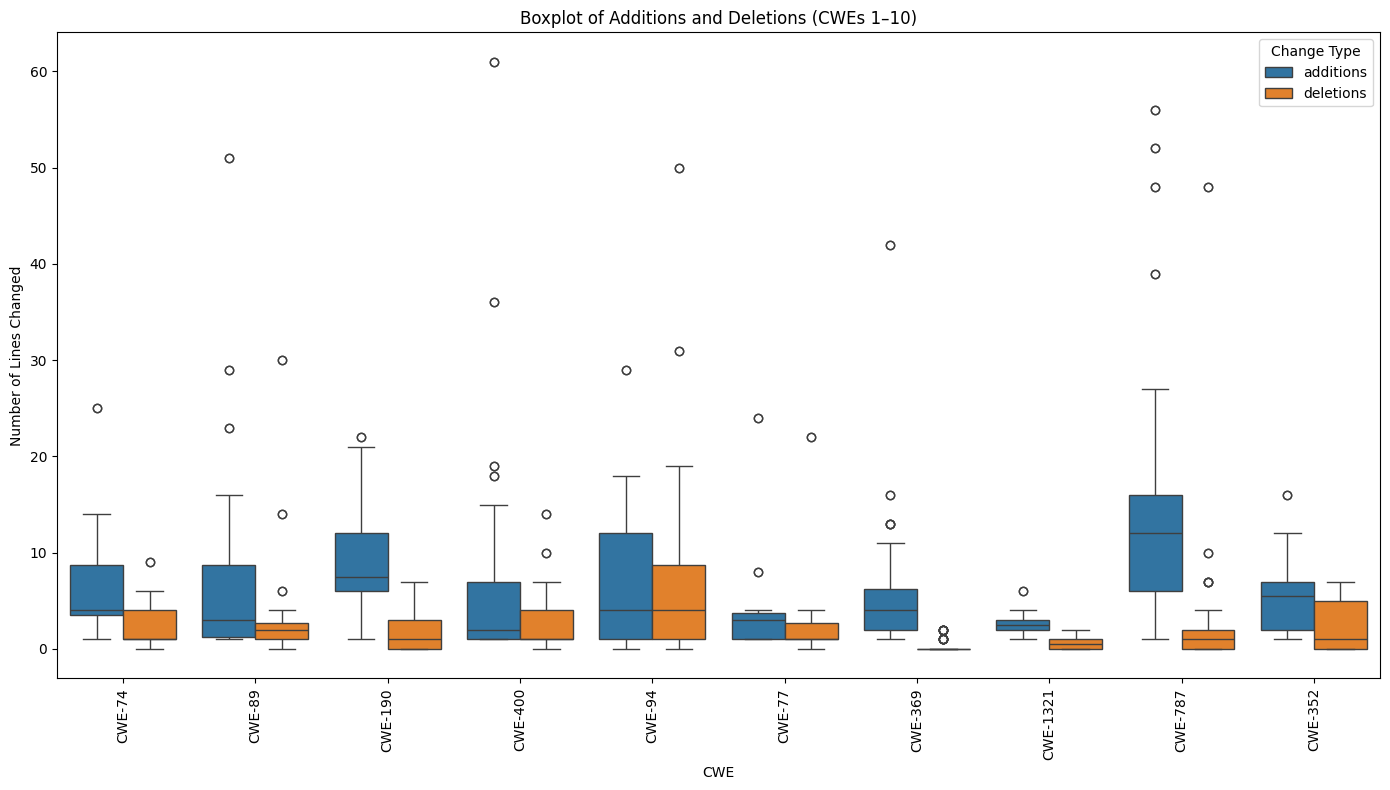

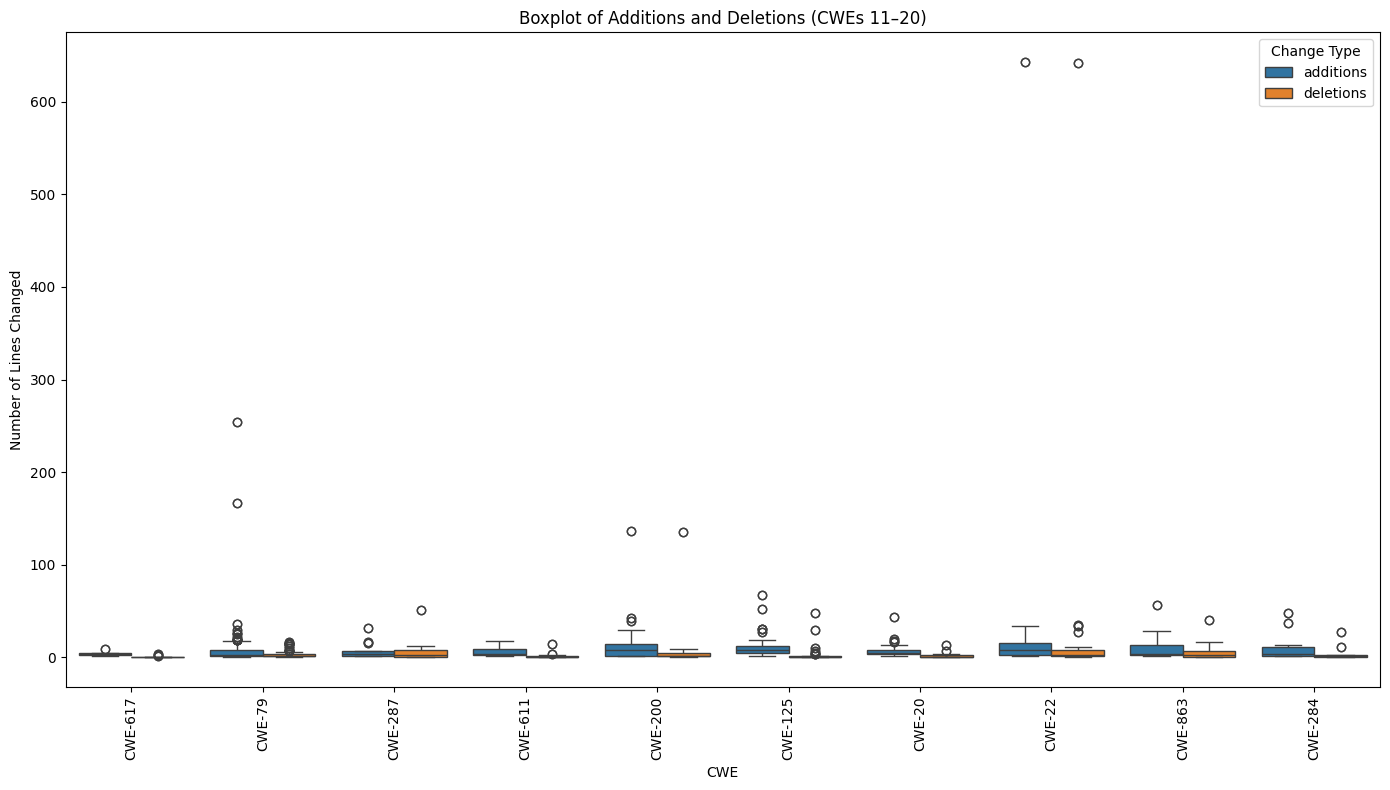

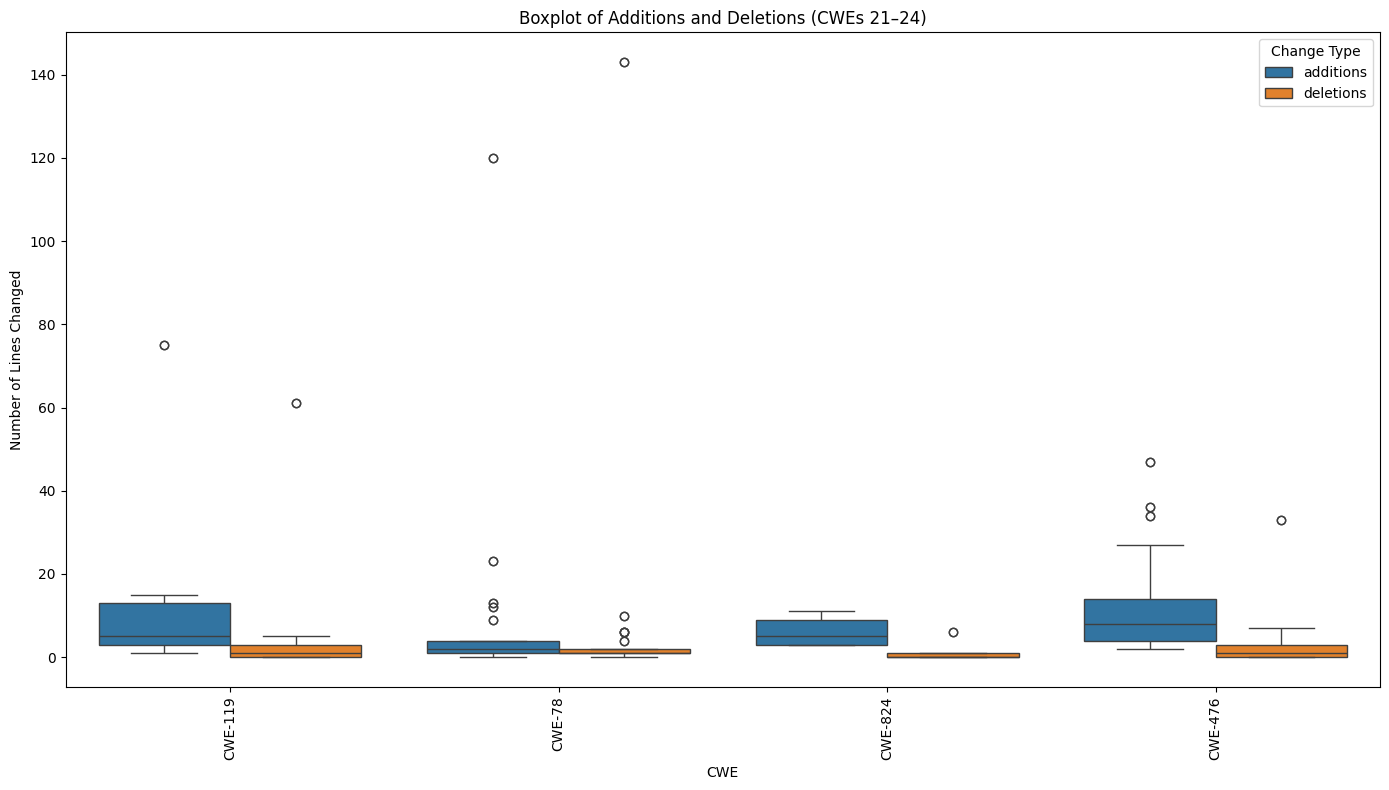

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure correct types
original_df["additions"] = original_df["additions"].astype(int)
original_df["deletions"] = original_df["deletions"].astype(int)

# Melt the DataFrame to long-form
melted_df = original_df.melt(id_vars=["cwe"], value_vars=["additions", "deletions"],
                    var_name="Change Type", value_name="Lines Changed")

# Get unique CWEs in chunks of 10
unique_cwes = melted_df["cwe"].unique()
chunk_size = 10

for i in range(0, len(unique_cwes), chunk_size):
    cwe_chunk = unique_cwes[i:i + chunk_size]
    chunk_df = melted_df[melted_df["cwe"].isin(cwe_chunk)]

    # Plot
    plt.figure(figsize=(14, 8))
    sns.boxplot(data=chunk_df, x="cwe", y="Lines Changed", hue="Change Type")
    plt.title(f"Boxplot of Additions and Deletions (CWEs {i + 1}–{i + len(cwe_chunk)})")
    plt.xlabel("CWE")
    plt.ylabel("Number of Lines Changed")
    plt.xticks(rotation=90)
    plt.legend(title="Change Type")
    plt.tight_layout()
    plt.show()


In [6]:
mean_additions = original_df.groupby("cwe")["additions"].mean()
mean_deletions = original_df.groupby("cwe")["deletions"].mean()

# create a dictionary such as 
#cwe_line_changes = {
#    'CWE-79': {'added': 120, 'deleted': 85},

cwe_line_changes = {}
for cwe in original_df["cwe"].unique():
    cwe_line_changes[cwe] = {
        'added': int(mean_additions[cwe]),
        'deleted': int(mean_deletions[cwe])
    }
print(cwe_line_changes)

{'CWE-74': {'added': 6, 'deleted': 2}, 'CWE-89': {'added': 8, 'deleted': 3}, 'CWE-190': {'added': 9, 'deleted': 2}, 'CWE-400': {'added': 6, 'deleted': 2}, 'CWE-94': {'added': 7, 'deleted': 8}, 'CWE-77': {'added': 4, 'deleted': 3}, 'CWE-369': {'added': 5, 'deleted': 0}, 'CWE-1321': {'added': 2, 'deleted': 0}, 'CWE-787': {'added': 16, 'deleted': 3}, 'CWE-352': {'added': 5, 'deleted': 2}, 'CWE-617': {'added': 4, 'deleted': 0}, 'CWE-79': {'added': 8, 'deleted': 2}, 'CWE-287': {'added': 7, 'deleted': 7}, 'CWE-611': {'added': 5, 'deleted': 1}, 'CWE-200': {'added': 17, 'deleted': 9}, 'CWE-125': {'added': 12, 'deleted': 3}, 'CWE-20': {'added': 7, 'deleted': 1}, 'CWE-22': {'added': 35, 'deleted': 32}, 'CWE-863': {'added': 10, 'deleted': 6}, 'CWE-284': {'added': 11, 'deleted': 4}, 'CWE-119': {'added': 11, 'deleted': 5}, 'CWE-78': {'added': 9, 'deleted': 8}, 'CWE-824': {'added': 5, 'deleted': 0}, 'CWE-476': {'added': 12, 'deleted': 2}}


In [7]:
folder_path = "../results_test/"

In [13]:
import os
import pandas as pd
import numpy as np
df = pd.DataFrame(columns=[
    "model",
    "cwe",
    "iqr",
    "mean",
    "median",
    "min",
    "max",
    "perplexity",
    "in_the_stack",
])
for file in os.listdir(folder_path):
    if file.endswith(".jsonl") and file not in ["NVD-CWE-Other.jsonl"]:
        with open(folder_path + "/" + file, "r") as f:
            lines = f.readlines()
            import json
            for line in lines:
                data = json.loads(line)
                # {"cwe": "CWE-16", "model": "openai-community/gpt2", "vulnerable": [1717.9267578125], "safe": [372.79498291015625]}
                model = data["model"]
                cwe = data["cwe"]
                vulnerable = data["vulnerable"]
                safe = data["safe"]
                # compute the IQR
                vulnerable = np.array(vulnerable)
                safe = np.array(safe)
                iqr_vulnerable = np.percentile(vulnerable, 75) - np.percentile(vulnerable, 25)
                iqr_safe = np.percentile(safe, 75) - np.percentile(safe, 25)

                # compute the mean
                mean_vulnerable = np.mean(vulnerable)
                mean_safe = np.mean(safe)

                # compute the median
                median_vulnerable = np.median(vulnerable)
                median_safe = np.median(safe)

                # compute the min
                min_vulnerable = np.min(vulnerable)
                min_safe = np.min(safe)

                # compute the max
                max_vulnerable = np.max(vulnerable)
                max_safe = np.max(safe)

                snippets = data["snippets"]
                
                vuln_snippets = []
                safe_snippets = []

                vuln_ids = []
                published_dates = []
                commit_hrefs = []
                scores = []
                additions = []
                deletions = []

                in_the_stack_vuln = []
                in_the_stack_safe = []

                for snippet in snippets:
                    if snippet["target"] == 1:
                        vuln_snippets.append(snippet["func"])
                        in_the_stack_vuln.append(snippet["in_the_stack"])
                    else:
                        safe_snippets.append(snippet["func"])
                        in_the_stack_safe.append(snippet["in_the_stack"])
                    
                    vuln_ids.append(snippet["vuln_id"])
                    published_dates.append(snippet["published_date"])
                    commit_hrefs.append(snippet["commit_href"])
                    scores.append(snippet["score"])
                    additions.append(snippet["additions"])
                    deletions.append(snippet["deletions"])
                # print the vulnerable snippets
                
            
                # dict_keys(['cwe', 'func', 'target', 'additions', 'deletions', 'total', 'vuln_id', 'score', 'published_date', 'commit_href'])
                # print(snippet)

                # Store the results in a dataframe
                results_vulnerable = pd.DataFrame({
                    "model": [model],
                    "cwe": [cwe],
                    "iqr": [iqr_vulnerable],
                    "mean": [mean_vulnerable],
                    "median": [median_vulnerable],
                    "min": [min_vulnerable],
                    "max": [max_vulnerable],
                    "perplexity": [vulnerable],
                    "snippets": [vuln_snippets],
                    "vuln_ids": [vuln_ids],
                    "published_dates": [published_dates],
                    "commit_hrefs": [commit_hrefs],
                    "scores": [scores],
                    "additions": [additions],
                    "deletions": [deletions],
                    "in_the_stack": [in_the_stack_vuln]
                })
                results_safe = pd.DataFrame({
                    "model": [model],
                    "cwe": [cwe+" Patched"],
                    "iqr": [iqr_safe],
                    "mean": [mean_safe],
                    "median": [median_safe],
                    "min": [min_safe],
                    "max": [max_safe],
                    "perplexity": [safe],
                    "snippets": [safe_snippets],
                    "vuln_ids": [vuln_ids],
                    "published_dates": [published_dates],
                    "commit_hrefs": [commit_hrefs],
                    "scores": [scores],
                    "additions": [additions],
                    "deletions": [deletions],
                    "in_the_stack": [in_the_stack_safe]
                })
                
                df = pd.concat([df, results_vulnerable, results_safe], ignore_index=True)
                

    
                

/var/folders/b4/lwfgccm95kqd2skcwvrt2fr00000gn/T/ipykernel_60980/3766780624.py:122: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, results_vulnerable, results_safe], ignore_index=True)


# Heatmaps with all the Vulnerabilities (not including Patched Versions) per Model

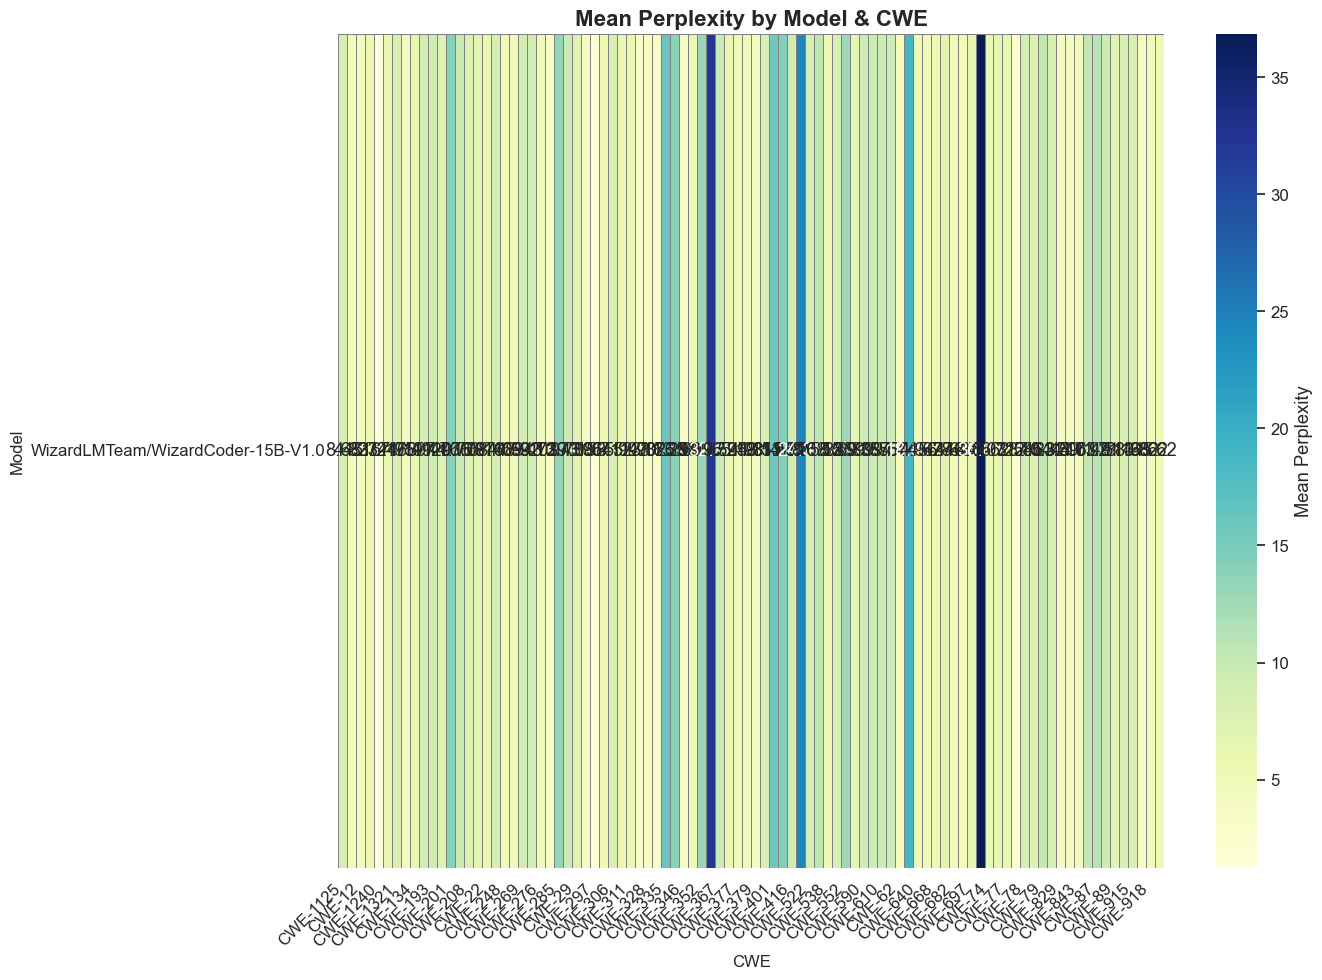

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filter out patched CWEs
non_patched_df = df[~df["cwe"].str.contains("Patched")]

# Get the unique CWEs and models
unique_cwes = non_patched_df["cwe"].unique()
unique_models = non_patched_df["model"].unique()

# Set the color palette for models
palette = sns.color_palette("colorblind", n_colors=len(unique_models))
model_colors = {model: palette[i] for i, model in enumerate(unique_models)}
cwe_colors = {cwe: palette[i % len(palette)] for i, cwe in enumerate(unique_cwes)}

# Compute mean values
mean_values = non_patched_df.groupby(["model", "cwe"]).mean(numeric_only=True).reset_index()

# Create a pivot table
pivot_table = mean_values.pivot(index="model", columns="cwe", values="mean")

# Plot the heatmap
plt.figure(figsize=(14, 10))
sns.set(font_scale=1.1)
sns.set_style("whitegrid")

heatmap = sns.heatmap(
    pivot_table,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Mean Perplexity'}
)

# Customize the appearance
plt.title("Mean Perplexity by Model & CWE", fontsize=16, weight='bold')
plt.xlabel("CWE", fontsize=12)
plt.ylabel("Model", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.grid(False)

plt.show()


In [15]:
df["CWE_Number"] = df["cwe"].str.extract(r'(\d+)').astype(int)
df = df.sort_values(by=["CWE_Number", "model"])
print(df.shape)
# Filter rows where len(perplexity) < 20
df = df[df["perplexity"].apply(len) > 20]
print(df.shape)
df

(184, 17)
(14, 17)


,model,cwe,iqr,mean,median,min,max,perplexity,in_the_stack,snippets,vuln_ids,published_dates,commit_hrefs,scores,additions,deletions,CWE_Number
140,WizardLMTeam/WizardCoder-15B-V1.0,CWE-20,4.775777,7.764019,6.148308,2.898510,18.851521,"[5.676312446594238, 4.127105712890625, 16.1468...","[True, True, True, False, True, True, False, T...",[ class MapStageOp : public OpKernel { OP_...,"[GHSA-278g-rq84-9hmg, GHSA-278g-rq84-9hmg, GHS...","[2021-08-25, 2021-08-25, 2022-01-06, 2022-01-0...",[https://github.com/tensorflow/tensorflow/comm...,"[5.5, 5.5, 8.2, 8.2, 5.5, 5.5, 9.8, 9.8, 8.8, ...","[2, 2, 4, 4, 4, 4, 7, 7, 13, 13, 1, 1, 6, 6, 6...","[0, 0, 2, 2, 0, 0, 2, 2, 4, 4, 1, 1, 3, 3, 0, ...",20
141,WizardLMTeam/WizardCoder-15B-V1.0,CWE-20 Patched,3.895571,5.667931,4.951563,1.977169,17.574678,"[4.570919036865234, 1.9771692752838135, 6.3466...","[True, True, True, False, True, True, False, T...",[ class MapStageOp : public OpKernel { OP_...,"[GHSA-278g-rq84-9hmg, GHSA-278g-rq84-9hmg, GHS...","[2021-08-25, 2021-08-25, 2022-01-06, 2022-01-0...",[https://github.com/tensorflow/tensorflow/comm...,"[5.5, 5.5, 8.2, 8.2, 5.5, 5.5, 9.8, 9.8, 8.8, ...","[2, 2, 4, 4, 4, 4, 7, 7, 13, 13, 1, 1, 6, 6, 6...","[0, 0, 2, 2, 0, 0, 2, 2, 4, 4, 1, 1, 3, 3, 0, ...",20
154,WizardLMTeam/WizardCoder-15B-V1.0,CWE-22,3.859567,6.164584,5.199112,2.393499,17.536339,"[8.680630683898926, 2.454801559448242, 8.89686...","[True, False, True, False, False, True, False,...","[ private void ExtractEntry(string destDir, Ta...","[GHSA-2x7h-96h5-rq84, GHSA-2x7h-96h5-rq84, GHS...","[2022-02-01, 2022-02-01, 2022-02-15, 2022-02-1...",[https://github.com/icsharpcode/SharpZipLib/co...,"[4.0, 4.0, 9.8, 9.8, 0.0, 0.0, 9.1, 9.1, 0.0, ...","[2, 2, 643, 643, 11, 11, 23, 23, 20, 20, 1, 1,...","[1, 1, 642, 642, 0, 0, 2, 2, 7, 7, 2, 2, 2, 2,...",22
155,WizardLMTeam/WizardCoder-15B-V1.0,CWE-22 Patched,4.420924,6.179814,4.208648,2.430889,25.810780,"[7.652802467346191, 2.4308886528015137, 4.8467...","[True, False, True, False, False, True, False,...","[ private void ExtractEntry(string destDir, Ta...","[GHSA-2x7h-96h5-rq84, GHSA-2x7h-96h5-rq84, GHS...","[2022-02-01, 2022-02-01, 2022-02-15, 2022-02-1...",[https://github.com/icsharpcode/SharpZipLib/co...,"[4.0, 4.0, 9.8, 9.8, 0.0, 0.0, 9.1, 9.1, 0.0, ...","[2, 2, 643, 643, 11, 11, 23, 23, 20, 20, 1, 1,...","[1, 1, 642, 642, 0, 0, 2, 2, 7, 7, 2, 2, 2, 2,...",22
174,WizardLMTeam/WizardCoder-15B-V1.0,CWE-78,6.831646,8.855007,6.429338,2.304703,29.942507,"[7.187116622924805, 5.85998010635376, 6.130472...","[False, False, True, True, True, False, True, ...","[ import { platform } from ""os""; import { exe...","[GHSA-2877-693q-pj33, GHSA-2877-693q-pj33, GHS...","[2022-03-07, 2022-03-07, 2022-05-14, 2022-05-1...",[https://github.com/genieacs/genieacs/commit/7...,"[9.8, 9.8, 7.5, 7.5, 9.8, 9.8, 8.6, 8.6, 9.8, ...","[13, 13, 0, 0, 1, 1, 2, 2, 1, 1, 2, 2, 120, 12...","[0, 0, 4, 4, 1, 1, 1, 1, 1, 1, 1, 1, 143, 143,...",78
175,WizardLMTeam/WizardCoder-15B-V1.0,CWE-78 Patched,4.105420,8.653708,5.938848,2.450998,36.566998,"[6.338003635406494, 15.181390762329102, 5.9902...","[False, False, True, True, True, False, True, ...","[ import { platform } from ""os""; import { exe...","[GHSA-2877-693q-pj33, GHSA-2877-693q-pj33, GHS...","[2022-03-07, 2022-03-07, 2022-05-14, 2022-05-1...",[https://github.com/genieacs/genieacs/commit/7...,"[9.8, 9.8, 7.5, 7.5, 9.8, 9.8, 8.6, 8.6, 9.8, ...","[13, 13, 0, 0, 1, 1, 2, 2, 1, 1, 2, 2, 120, 12...","[0, 0, 4, 4, 1, 1, 1, 1, 1, 1, 1, 1, 143, 143,...",78
118,WizardLMTeam/WizardCoder-15B-V1.0,CWE-79,7.294524,10.320927,6.957760,1.742366,106.088615,"[13.371914863586426, 6.061926364898682, 19.561...","[False, False, True, False, True, False, False...",[ public function audit(Request $request) { ...,"[GHSA-2cqg-q7jm-j35c, GHSA-2cqg-q7jm-j35c, GHS...","[2021-11-15, 2021-11-15, 2022-06-03, 2022-06-0...",[https://github.com/snipe/snipe-it/commit/9ed1...,"[3.9, 3.9, 6.1, 6.1, 8.8, 8.8, 5.4, 5.4, 5.4, ...","[1, 1, 2, 2, 1, 1, 1, 1, 1, 1,

In [16]:
df["model"].value_counts()

model
WizardLMTeam/WizardCoder-15B-V1.0    14
Name: count, dtype: int64

In [17]:
accpeted_models = [
    'Salesforce/codegen-6B-multi', 
    'WizardLMTeam/WizardCoder-15B-V1.0',
    'lmsys/vicuna-7b-v1.5', 
    "lmsys/vicuna-13b-v1.5",
    # 'Qwen/Qwen2.5-Coder-0.5B-Instruct',
    # 'deepseek-ai/deepseek-coder-6.7b-base',
    # 'meta-llama/CodeLlama-7b-hf', 
    # 'meta-llama/Llama-3.2-3B-Instruct'
]

prettier_names = {
    "openai-community/gpt2": "GPT-2",
    "microsoft/codebert-base": "CodeBERT",
    "WizardLMTeam/WizardCoder-15B-V1.0": "WizardCoder 15B",
    "Salesforce/codegen-6B-multi": "Codegen 6B",
    "lmsys/vicuna-7b-v1.5": "Vicuna 7B",
    "lmsys/vicuna-13b-v1.5": "Vicuna 13B",
    "Qwen/Qwen2.5-Coder-0.5B-Instruct": "Qwen 0.5B",
    "deepseek-ai/deepseek-coder-6.7b-base": "Deepseek 6.7B",
    "meta-llama/CodeLlama-7b-hf": "CodeLlama 7B",
    "meta-llama/Llama-3.2-3B-Instruct": "Llama 3.2B"
}


df = df[df["model"].isin(accpeted_models)]
df.head(2)

,model,cwe,iqr,mean,median,min,max,perplexity,in_the_stack,snippets,vuln_ids,published_dates,commit_hrefs,scores,additions,deletions,CWE_Number
140,WizardLMTeam/WizardCoder-15B-V1.0,CWE-20,4.775777,7.764019,6.148308,2.898510,18.851521,"[5.676312446594238, 4.127105712890625, 16.1468...","[True, True, True, False, True, True, False, T...",[ class MapStageOp : public OpKernel { OP_...,"[GHSA-278g-rq84-9hmg, GHSA-278g-rq84-9hmg, GHS...","[2021-08-25, 2021-08-25, 2022-01-06, 2022-01-0...",[https://github.com/tensorflow/tensorflow/comm...,"[5.5, 5.5, 8.2, 8.2, 5.5, 5.5, 9.8, 9.8, 8.8, ...","[2, 2, 4, 4, 4, 4, 7, 7, 13, 13, 1, 1, 6, 6, 6...","[0, 0, 2, 2, 0, 0, 2, 2, 4, 4, 1, 1, 3, 3, 0, ...",20
141,WizardLMTeam/WizardCoder-15B-V1.0,CWE-20 Patched,3.895571,5.667931,4.951563,1.977169,17.574678,"[4.570919036865234, 1.9771692752838135, 6.3466...","[True, True, True, False, True, True, False, T...",[ class MapStageOp : public OpKernel { OP_...,"[GHSA-278g-rq84-9hmg, GHSA-278g-rq84-9hmg, GHS...","[2021-08-25, 2021-08-25, 2022-01-06, 2022-01-0...",[https://github.com/tensorflow/tensorflow/comm...,"[5.5, 5.5, 8.2, 8.2, 5.5, 5.5, 9.8, 9.8, 8.8, ...","[2, 2, 4, 4, 4, 4, 7, 7, 13, 13, 1, 1, 6, 6, 6...","[0, 0, 2, 2, 0, 0, 2, 2, 4, 4, 1, 1, 3, 3, 0, ...",20


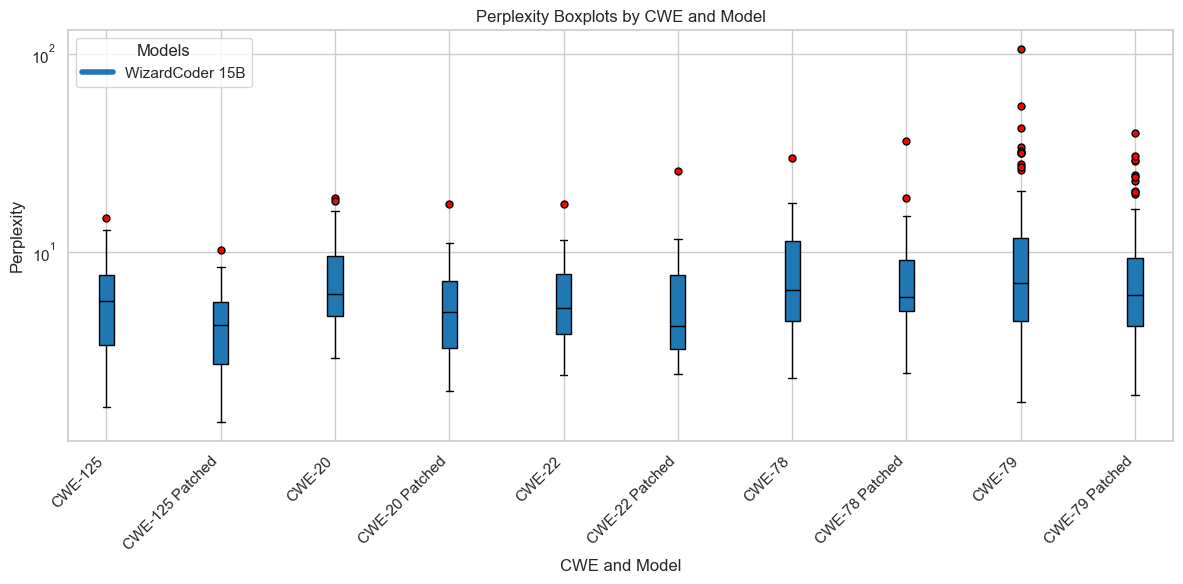

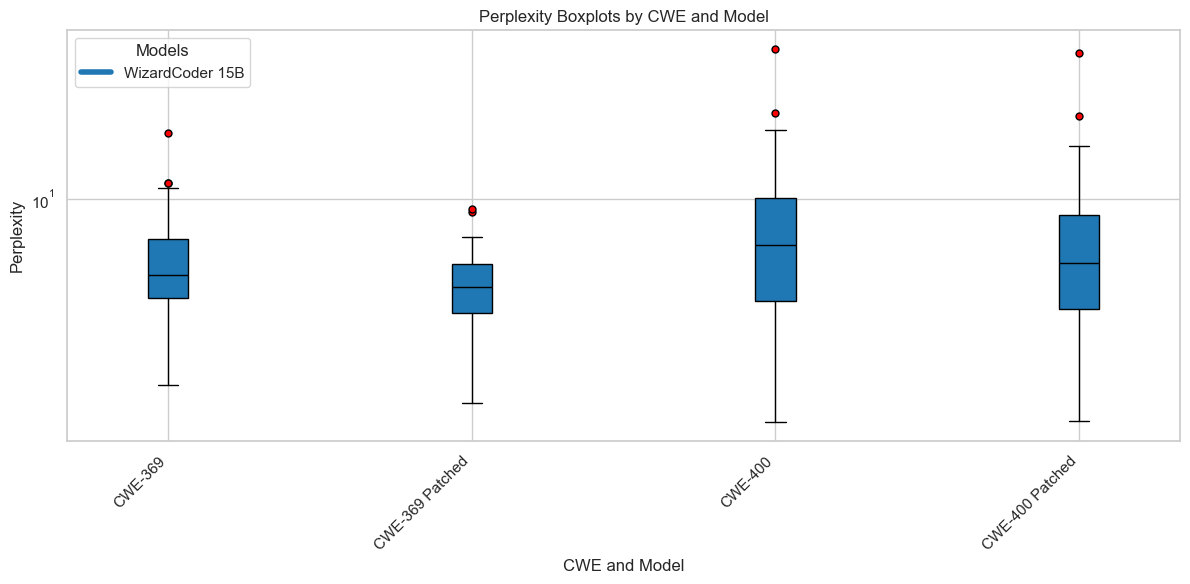

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

def plot_grouped_boxplots(df, cwe_subset, model_colors):
    plt.figure(figsize=(12, 6))
    
    # Filter data for selected CWEs
    subset_df = df[df["cwe"].isin(cwe_subset)]
    
    # Sort dataframe by CWE and model
    sorted_df = subset_df.sort_values(by=['cwe', 'model'])
    
    positions = []
    labels = []
    idx = 0
    cwe_spacing = 1.5  # Control spacing between different CWEs
    model_spacing = 0.3  # Control spacing between models under the same CWE

    legend_handles = {}  # To store legend handles
    
    # Grouping by CWE
    for cwe in sorted_df["cwe"].unique():
        cwe_df = sorted_df[sorted_df["cwe"] == cwe]
        cwe_base_idx = idx
        
        for j, model in enumerate(cwe_df["model"].unique()):
            model_df = cwe_df[cwe_df["model"] == model]
            pos = cwe_base_idx + j * model_spacing

            # print("----")
            # print(cwe)
            # print(len(model_df["perplexity"]))
            # print(model_df["perplexity"])
            # print(model)
            # Create boxplot and capture its elements
            box = plt.boxplot(
                model_df["perplexity"],
                positions=[pos],
                widths=0.2,
                patch_artist=True,
                medianprops=dict(color="black"),
                whiskerprops=dict(color="black"),
                capprops=dict(color="black"),
                flierprops=dict(marker="o", markersize=5, markerfacecolor="red"),
            )
            
            # Color the boxes appropriately
            for b in box['boxes']:
                b.set_facecolor(model_colors[model])

            # Store legend info
            if model not in legend_handles:
                legend_handles[model] = plt.Line2D([0], [0], color=model_colors[model], lw=4, label=prettier_names[model])

            if cwe not in labels:
                labels.append(cwe)
            else:
                labels.append("")
            positions.append(pos)
            
        # Update the index to keep CWEs close together
        idx = pos + cwe_spacing
    # Adjust x-axis labels
    plt.xticks(positions, labels, rotation=45, ha="right")
    plt.xlabel("CWE and Model")
    plt.ylabel("Perplexity")
    plt.title("Perplexity Boxplots by CWE and Model")
    plt.legend(handles=legend_handles.values(), title="Models")  # Add legend
    plt.tight_layout()
    plt.yscale("log")
    plt.show()

# Get unique CWE values
unique_cwes = df["cwe"].unique()

# Assign colors to models
unique_models = df['model'].unique()
model_colors = {model: plt.cm.tab10(i % 10) for i, model in enumerate(unique_models)}

# Define batch size
batch_size = 10

# Generate plots in batches
for i in range(0, len(unique_cwes), batch_size):
    cwe_batch = unique_cwes[i:i+batch_size]
    plot_grouped_boxplots(df, cwe_batch, model_colors)

## Perplexity Diff

In [19]:
# for each cwe and model, compute the diff in perplexity for the cwe and the patched cwe
# and store it in a new column called diff

unique_models = df['model'].unique()
cwes = df['cwe'].unique()
cwes = [cwe for cwe in cwes if "Patched" not in cwe]

test_df = df.copy()
# make it a list in every row for the column "diff"
test_df["diff"] = test_df["perplexity"].apply(lambda x: [0] * len(x))
for i, row in test_df.iterrows():
    # for each model, compute the diff in perplexity for the cwe and the patched cwe
    if row["cwe"] in cwes and row["model"] in unique_models:
        # get the patched cwe
        patched_cwe = row["cwe"] + " Patched"
        # get the perplexity for the cwe and the patched cwe
        cwe_perplexity = test_df[(test_df["cwe"] == row["cwe"]) & (test_df["model"] == row["model"])]["perplexity"].values[0]
        patched_cwe_perplexity = test_df[(test_df["cwe"] == patched_cwe) & (test_df["model"] == row["model"])]["perplexity"].values[0]
        # compute the diff
        diff = cwe_perplexity - patched_cwe_perplexity
        # store the diff in the new column
        test_df.at[i, "diff"] = diff
    else:
        # if the cwe is not in the list, set the diff to 0
        test_df.at[i, "diff"] = 0


test_df = test_df[~test_df["cwe"].str.contains("Patched")]

In [20]:
# Print the code snipptes where the diff is < 0
for i, row in test_df.iterrows():
    for j, diff in enumerate(row["diff"]):
        if diff < 0:
            print("CWE: ", row["cwe"])
            print("Model: ", row["model"])
            print("Diff: ", diff)
            print("Snippet: ", row["snippets"][j])
            print("Published Date: ", row["published_dates"][j])
            print("Commit Href: ", row["commit_hrefs"][j])
            print("Score: ", row["scores"][j])
            print("Additions: ", row["additions"][j])
            print("Deletions: ", row["deletions"][j])
            print("\n")

CWE:  CWE-20
Model:  WizardLMTeam/WizardCoder-15B-V1.0
Diff:  -0.0028777122497558594
Snippet:   THE SOFTWARE.     <dependency>       <groupId>commons-fileupload</groupId>       <artifactId>commons-fileupload</artifactId>       <version>1.3.1-jenkins-1</version>     </dependency>      <!-- offline profiler API to put in the classpath if we need it -->
Published Date:  2019-10-22
Commit Href:  https://github.com/Automattic/mongoose/commit/f3eca5b94d822225c04e96cbeed9f095afb3c31c
Score:  9.1
Additions:  6
Deletions:  0


CWE:  CWE-20
Model:  WizardLMTeam/WizardCoder-15B-V1.0
Diff:  -0.18642473220825195
Snippet:   function parsePath(path) {   var str = path.replace(/([^\\])\[/g, '$1.[');   var parts = str.match(/(\\\.|[^.]+?)+/g);   return parts.map(function mapMatches(value) {     var regexp = /^\[(\d+)\]$/;     var mArr = regexp.exec(value);     var parsed = null;
Published Date:  2022-02-15
Commit Href:  https://github.com/opencontainers/umoci/commit/d9efc31daf2206f7d3fdb839863cf7a576a2

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

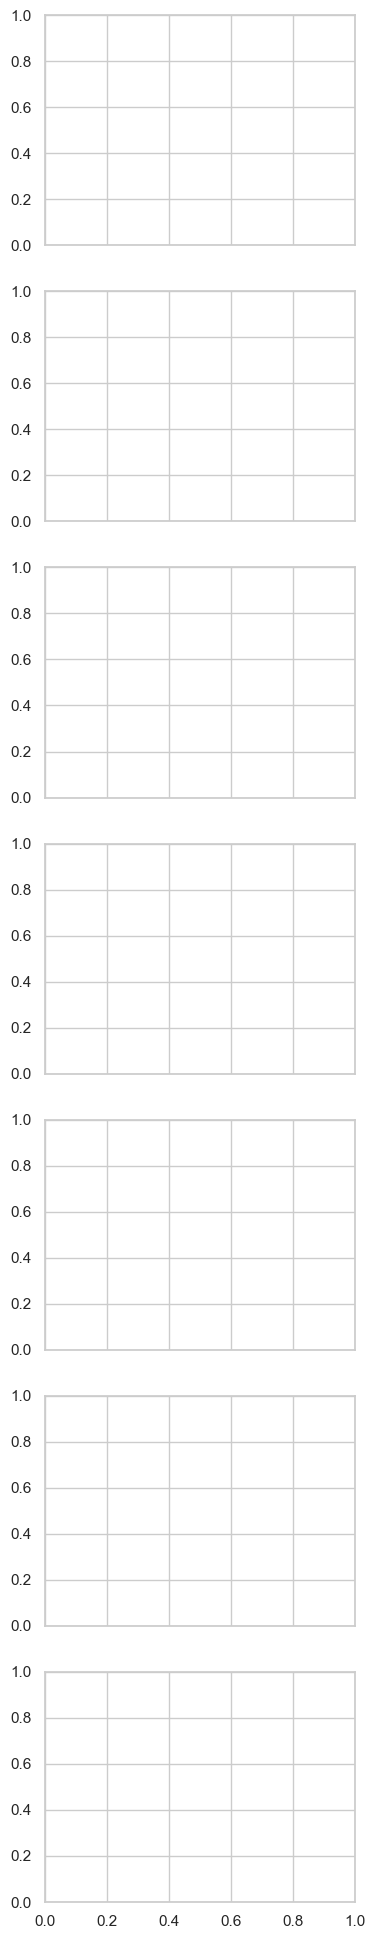

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_grouped_histograms_diff(df, cwe_subset, model_colors, bins=10):
    subset_df = df[df["cwe"].isin(cwe_subset)]
    
    n_rows = len(cwe_subset)
    n_cols = len(unique_models)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows), sharex=True, sharey=True)
    axes = np.array(axes)

    for row_idx, cwe in enumerate(cwe_subset):
        for col_idx, model in enumerate(unique_models):
            ax = axes[row_idx, col_idx] if n_rows > 1 else axes[col_idx]
            
            filtered = subset_df[(subset_df["cwe"] == cwe) & (subset_df["model"] == model)]
            sns.histplot(filtered["diff"].tolist(),
                         bins=bins, color=model_colors[model], ax=ax, kde=True, stat="percent" )
            
            if row_idx == 0:
                ax.set_title(prettier_names[model], fontsize=10)
            if col_idx == 0:
                ax.set_ylabel(f"{cwe}", fontsize=10)
            
            ax.grid(True, linestyle="--", alpha=0.5)
            ax.set_xlabel("Diff" if row_idx == n_rows - 1 else "")

    fig.suptitle("Histograms of Diff by CWE and Model", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

batch_size = 9
for i in range(0, len(cwes), batch_size):
    cwe_batch = cwes[i:i+batch_size]
    plot_grouped_histograms_diff(test_df, cwe_batch, model_colors)


# Boxplots with all the Vulnerabilities (not including Patched Versions)

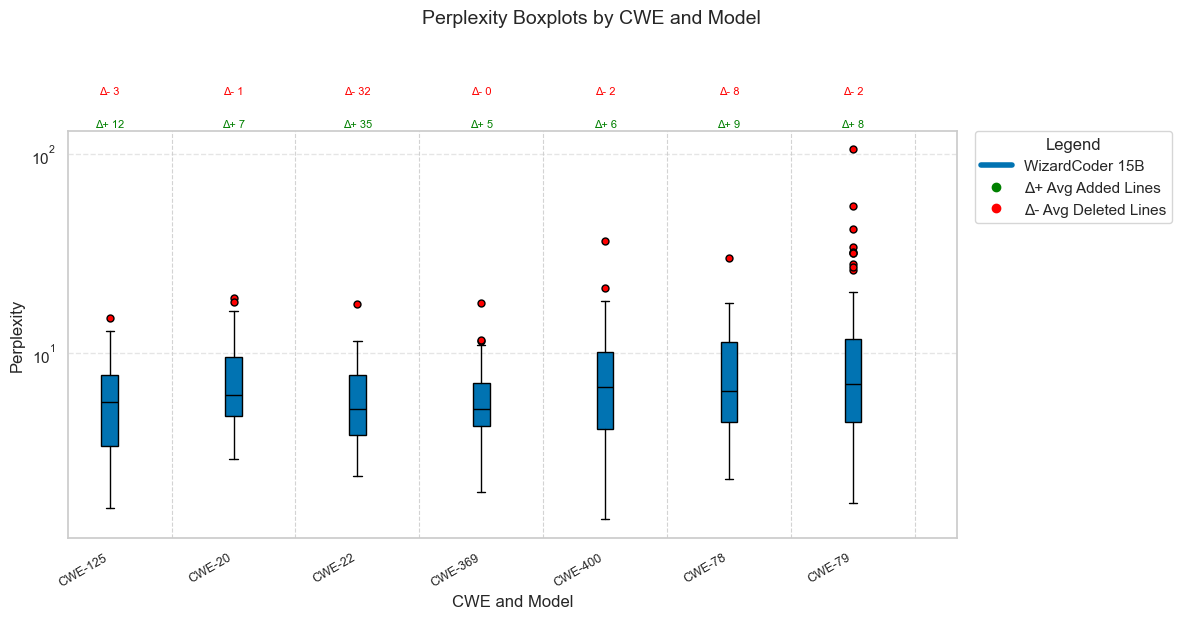

In [22]:


def plot_grouped_boxplots_weak(df, cwe_subset, model_colors):
    plt.figure(figsize=(12, 6))
    
    # Filter data for selected CWEs
    subset_df = df[df["cwe"].isin(cwe_subset)]
    
    # Sort dataframe by CWE and model
    sorted_df = subset_df.sort_values(by=['cwe', 'model'])
    
    positions = []
    labels = []
    idx = 0
    cwe_spacing = 1.5  # Control spacing between different CWEs
    model_spacing = 0.3  # Control spacing between models under the same CWE

    legend_handles = {}  # To store legend handles
    
    # Grouping by CWE
    for cwe in sorted_df["cwe"].unique():
        cwe_df = sorted_df[sorted_df["cwe"] == cwe]
        cwe_base_idx = idx
        
        for j, model in enumerate(cwe_df["model"].unique()):
            model_df = cwe_df[cwe_df["model"] == model]
            pos = cwe_base_idx + j * model_spacing

            box = plt.boxplot(
                model_df["perplexity"],
                positions=[pos],
                widths=0.2,
                patch_artist=True,
                medianprops=dict(color="black"),
                whiskerprops=dict(color="black"),
                capprops=dict(color="black"),
                flierprops=dict(marker="o", markersize=5, markerfacecolor="red"),
            )
            
            # Color the boxes appropriately
            for b in box['boxes']:
                b.set_facecolor(model_colors[model])

            # Store legend info
            if model not in legend_handles:
                legend_handles[model] = plt.Line2D([0], [0], color=model_colors[model], lw=4, label=prettier_names[model])

            if cwe not in labels:
                labels.append(cwe)
            else:
                labels.append("")
            positions.append(pos)
            
        # Update the index to keep CWEs close together
        idx = pos + cwe_spacing
        
        # Optional: draw divider between CWE groups
        plt.axvline(x=idx - (cwe_spacing / 2), color='lightgray', linestyle='--', linewidth=0.8, zorder=0)

        # Get average position of this CWE group to place annotation
        group_positions = [cwe_base_idx + j * model_spacing for j in range(len(cwe_df["model"].unique()))]
        group_center = np.mean(group_positions)

        # Add annotation (if data is available)
        if cwe in cwe_line_changes:
            change_info = cwe_line_changes[cwe]
            
            plt.annotate(
                f'Δ+ {change_info["added"]}',
                xy=(group_center, 1.01),
                xycoords=('data', 'axes fraction'),
                ha='center', fontsize=8, color='green'
            )
            plt.annotate(
                f'Δ- {change_info["deleted"]}',
                xy=(group_center, 1.09),
                xycoords=('data', 'axes fraction'),
                ha='center', fontsize=8, color='red'
            )
            

    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.grid(axis='x', visible=False)

    # Add annotation legend handles (for Δ+ and Δ-)
    annotation_legend = [
        plt.Line2D([0], [0], color='green', lw=0, marker='o', label='Δ+ Avg Added Lines'),
        plt.Line2D([0], [0], color='red', lw=0, marker='o', label='Δ- Avg Deleted Lines')
    ]

    # Combine model and annotation legends
    all_legend_handles = list(legend_handles.values()) + annotation_legend

    # Plot the combined legend
    plt.legend(handles=all_legend_handles, title="Legend", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
    # Adjust x-axis labels
    plt.xticks(positions, labels, rotation=30, ha="right", fontsize=9)
    plt.xlabel("CWE and Model")
    plt.ylabel("Perplexity")
    plt.suptitle("Perplexity Boxplots by CWE and Model", y=1.03, fontsize=14)
    #plt.title("Perplexity Boxplots by CWE and Model")
    #plt.legend(handles=legend_handles.values(), title="Models", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
    #plt.legend(handles=legend_handles.values(), title="Models")  # Add legend
    plt.tight_layout()
    plt.yscale("log")
    plt.show()

non_patched_df = df[~df["cwe"].str.contains("Patched")]

sns.set_theme(style="whitegrid")

# Get unique CWE values
unique_cwes = non_patched_df["cwe"].unique()

# Assign colors to models
unique_models = non_patched_df['model'].unique()
palette = sns.color_palette("colorblind", n_colors=len(unique_models))
model_colors = {model: palette[i] for i, model in enumerate(unique_models)}

medianprops=dict(color="black", linewidth=2)
whiskerprops=dict(color="gray", linestyle='--', linewidth=1)
capprops=dict(color="gray", linewidth=1)
flierprops=dict(marker="o", markersize=4, markerfacecolor="gray", alpha=0.3)


# Define batch size
batch_size = 11

# Generate plots in batches
for i in range(0, len(unique_cwes), batch_size):
    cwe_batch = unique_cwes[i:i+batch_size]
    plot_grouped_boxplots_weak(non_patched_df, cwe_batch, model_colors)

# Heatmaps with all the Vulnerabilities (not including Patched Versions) per Model

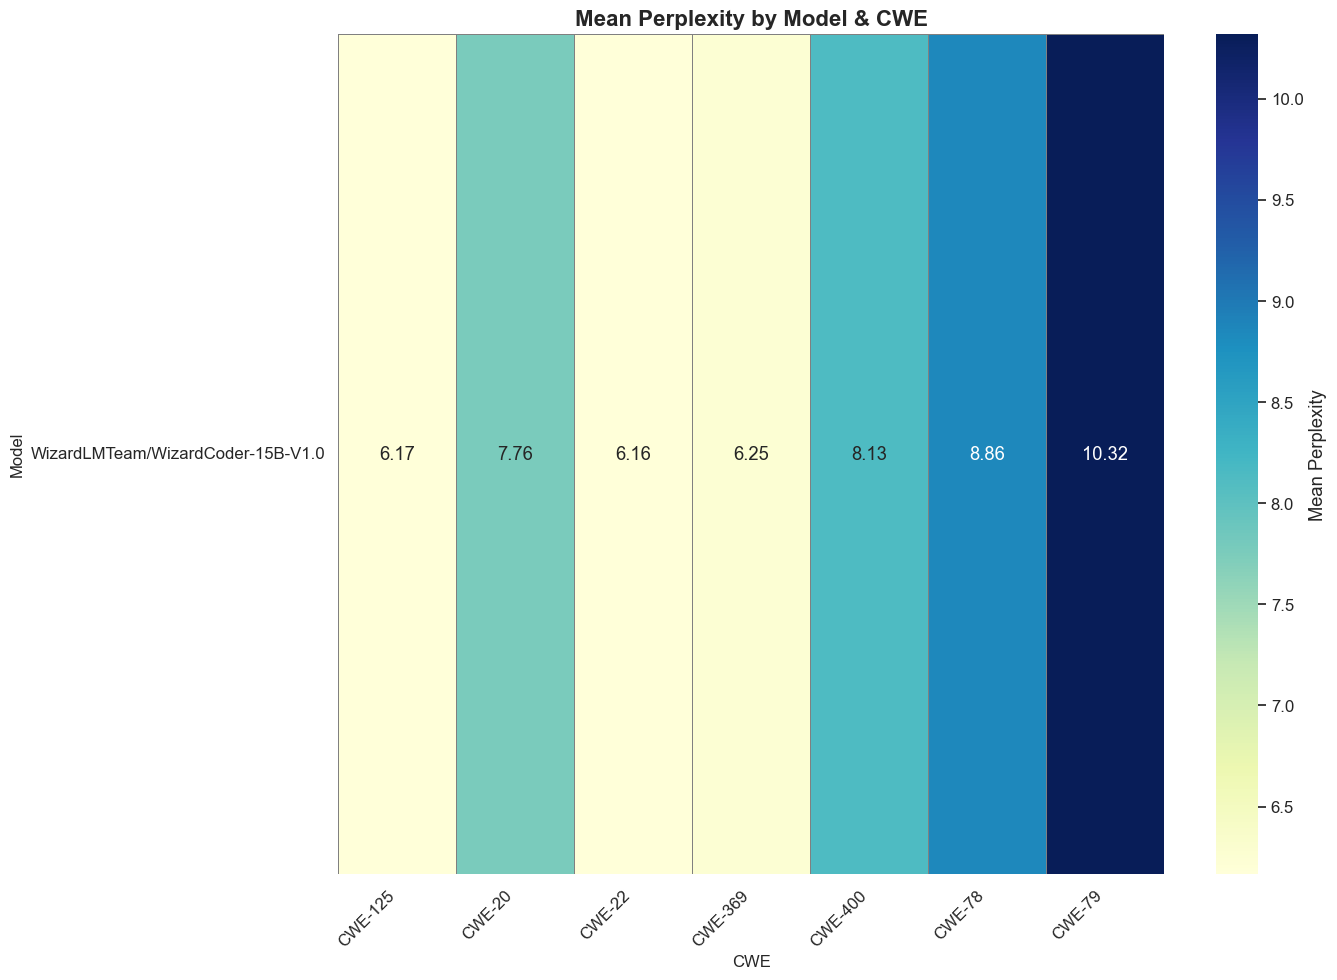

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filter out patched CWEs
non_patched_df = df[~df["cwe"].str.contains("Patched")]

# Get the unique CWEs and models
unique_cwes = non_patched_df["cwe"].unique()
unique_models = non_patched_df["model"].unique()

# Set the color palette for models
palette = sns.color_palette("colorblind", n_colors=len(unique_models))
model_colors = {model: palette[i] for i, model in enumerate(unique_models)}
cwe_colors = {cwe: palette[i % len(palette)] for i, cwe in enumerate(unique_cwes)}

# Compute mean values
mean_values = non_patched_df.groupby(["model", "cwe"]).mean(numeric_only=True).reset_index()

# Create a pivot table
pivot_table = mean_values.pivot(index="model", columns="cwe", values="mean")

# Plot the heatmap
plt.figure(figsize=(14, 10))
sns.set(font_scale=1.1)
sns.set_style("whitegrid")

heatmap = sns.heatmap(
    pivot_table,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Mean Perplexity'}
)

# Customize the appearance
plt.title("Mean Perplexity by Model & CWE", fontsize=16, weight='bold')
plt.xlabel("CWE", fontsize=12)
plt.ylabel("Model", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.grid(False)

plt.show()


# Heatmaps with all the Vulnerabilities (compare between Code from the stack and not)

In [24]:
# Filter out patched CWEs
non_patched_df = df[~df["cwe"].str.contains("Patched", na=False)]

def filter_in_the_stack_snippets(df, in_the_stack=True, has_diff_column=False):
    filtered_rows = []

    for _, row in df.iterrows():
        filtered_snippets = []
        filtered_vuln_ids = []
        filtered_published_dates = []
        filtered_commit_hrefs = []
        filtered_scores = []
        filtered_additions = []
        filtered_deletions = []
        filtered_in_the_stack = []
        filtered_perplexity = []
        
        filtered_diff = []

        for j, snippet in enumerate(row["snippets"]):
            if row["in_the_stack"][j] == in_the_stack:
                filtered_snippets.append(snippet)
                filtered_vuln_ids.append(row["vuln_ids"][j])
                filtered_published_dates.append(row["published_dates"][j])
                filtered_commit_hrefs.append(row["commit_hrefs"][j])
                filtered_scores.append(row["scores"][j])
                filtered_additions.append(row["additions"][j])
                filtered_deletions.append(row["deletions"][j])
                filtered_in_the_stack.append(row["in_the_stack"][j])
                filtered_perplexity.append(row["perplexity"][j])
                if has_diff_column:
                    filtered_diff.append(row["diff"][j])

        


        if filtered_snippets:
            iqr = np.percentile(filtered_perplexity, 75) - np.percentile(filtered_perplexity, 25)
            mean = np.mean(filtered_perplexity)
            median = np.median(filtered_perplexity)
            min_val = np.min(filtered_perplexity)
            max_val = np.max(filtered_perplexity)


            filtered_rows.append({
                "model": row["model"],
                "cwe": row["cwe"],
                "iqr": iqr,
                "mean": mean,
                "median": median,
                "min": min_val,
                "max": max_val,
                "perplexity": filtered_perplexity,
                "snippets": filtered_snippets,
                "vuln_ids": filtered_vuln_ids,
                "published_dates": filtered_published_dates,
                "commit_hrefs": filtered_commit_hrefs,
                "scores": filtered_scores,
                "additions": filtered_additions,
                "deletions": filtered_deletions,
                "in_the_stack": filtered_in_the_stack,
                "diff": filtered_diff if has_diff_column else None
            })

    return pd.DataFrame(filtered_rows)



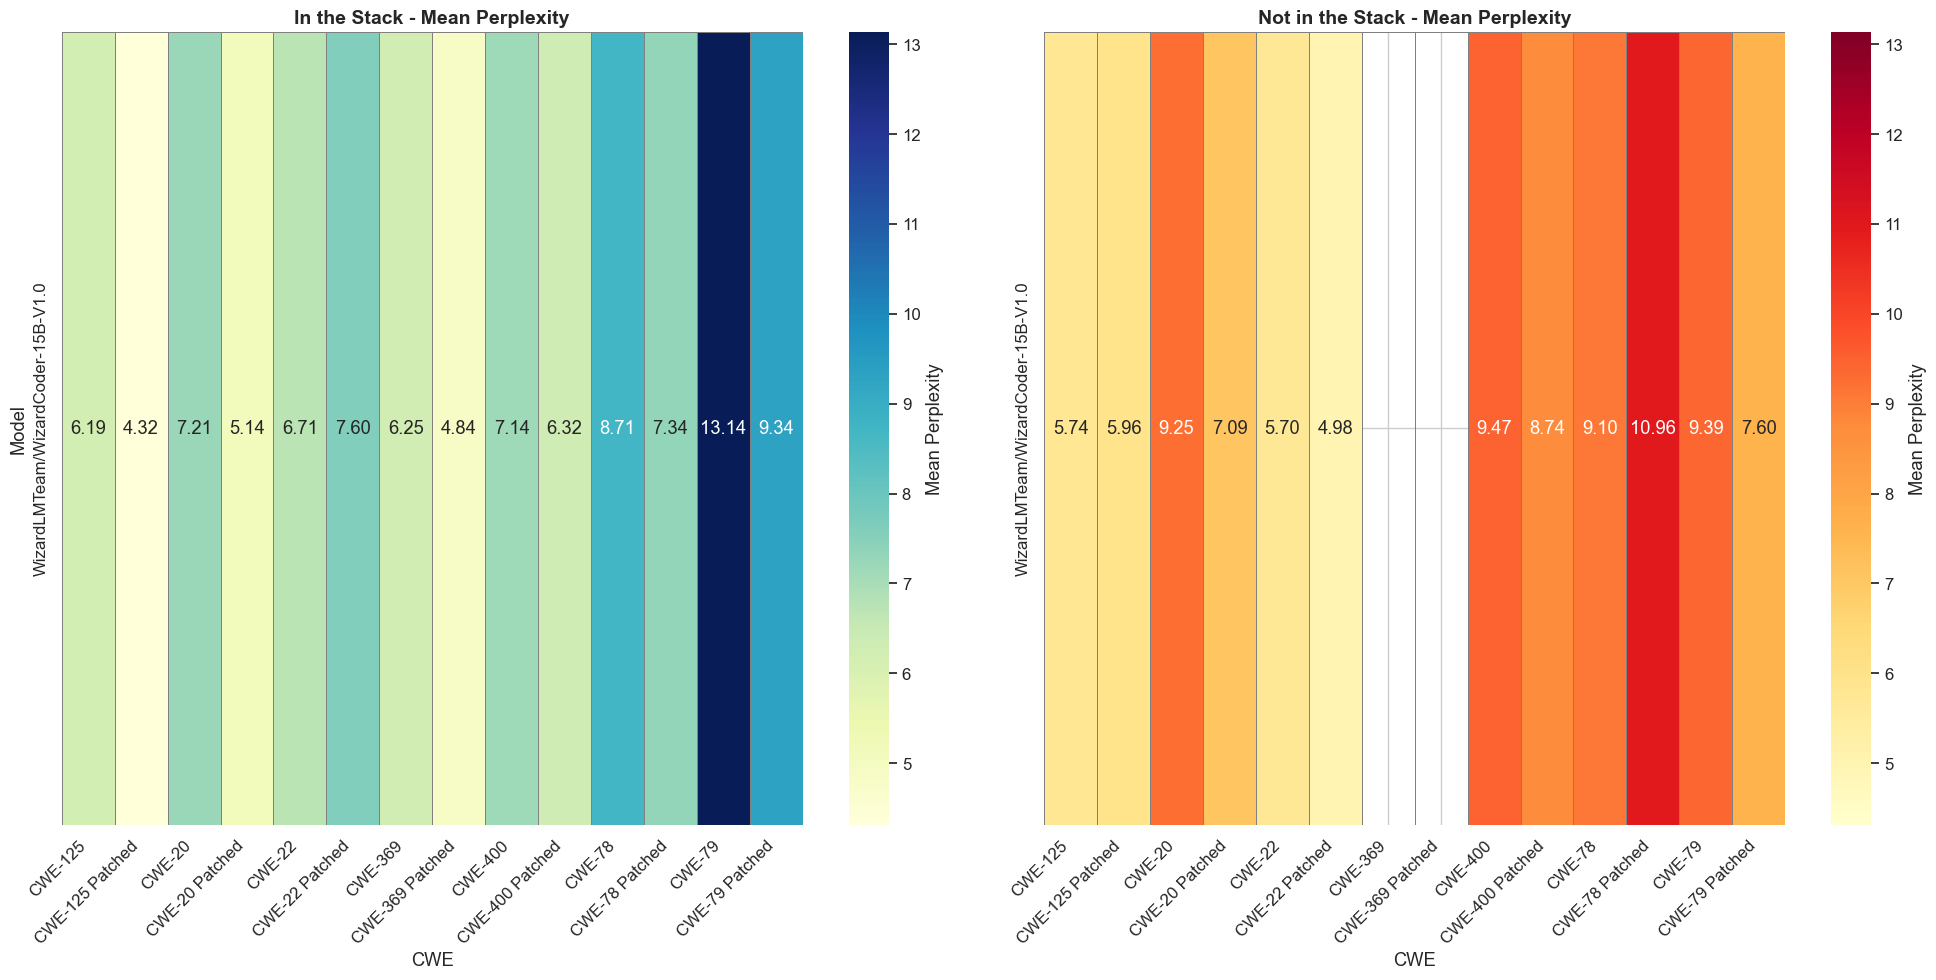

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filtered DataFrames
in_the_stack_df = filter_in_the_stack_snippets(df, in_the_stack=True)
non_in_the_stack_df = filter_in_the_stack_snippets(df, in_the_stack=False)

# Helper function to prepare pivot data
def prepare_pivot(df):
    mean_values = df.groupby(["model", "cwe"]).mean(numeric_only=True).reset_index()
    return mean_values.pivot(index="model", columns="cwe", values="mean")

# Prepare pivot tables
pivot_in_stack = prepare_pivot(in_the_stack_df)
pivot_not_in_stack = prepare_pivot(non_in_the_stack_df)

# Get union of all columns (CWEs) and rows (models)
all_cwes = sorted(set(pivot_in_stack.columns).union(pivot_not_in_stack.columns))
all_models = sorted(set(pivot_in_stack.index).union(pivot_not_in_stack.index))

# Reindex both pivot tables to ensure same shape and ordering
pivot_in_stack = pivot_in_stack.reindex(index=all_models, columns=all_cwes)
pivot_not_in_stack = pivot_not_in_stack.reindex(index=all_models, columns=all_cwes)

# Plot settings
plt.figure(figsize=(20, 10))
sns.set(font_scale=1.1)
sns.set_style("whitegrid")

# Heatmap 1: In the Stack
plt.subplot(1, 2, 1)
sns.heatmap(
    pivot_in_stack,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Mean Perplexity'},
    vmin=min(pivot_in_stack.min().min(), pivot_not_in_stack.min().min()),
    vmax=max(pivot_in_stack.max().max(), pivot_not_in_stack.max().max())
)
plt.title("In the Stack - Mean Perplexity", fontsize=14, weight='bold')
plt.xlabel("CWE")
plt.ylabel("Model")
plt.xticks(rotation=45, ha='right')

# Heatmap 2: Not In the Stack
plt.subplot(1, 2, 2)
sns.heatmap(
    pivot_not_in_stack,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Mean Perplexity'},
    vmin=min(pivot_in_stack.min().min(), pivot_not_in_stack.min().min()),
    vmax=max(pivot_in_stack.max().max(), pivot_not_in_stack.max().max())
)
plt.title("Not in the Stack - Mean Perplexity", fontsize=14, weight='bold')
plt.xlabel("CWE")
plt.ylabel("")

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


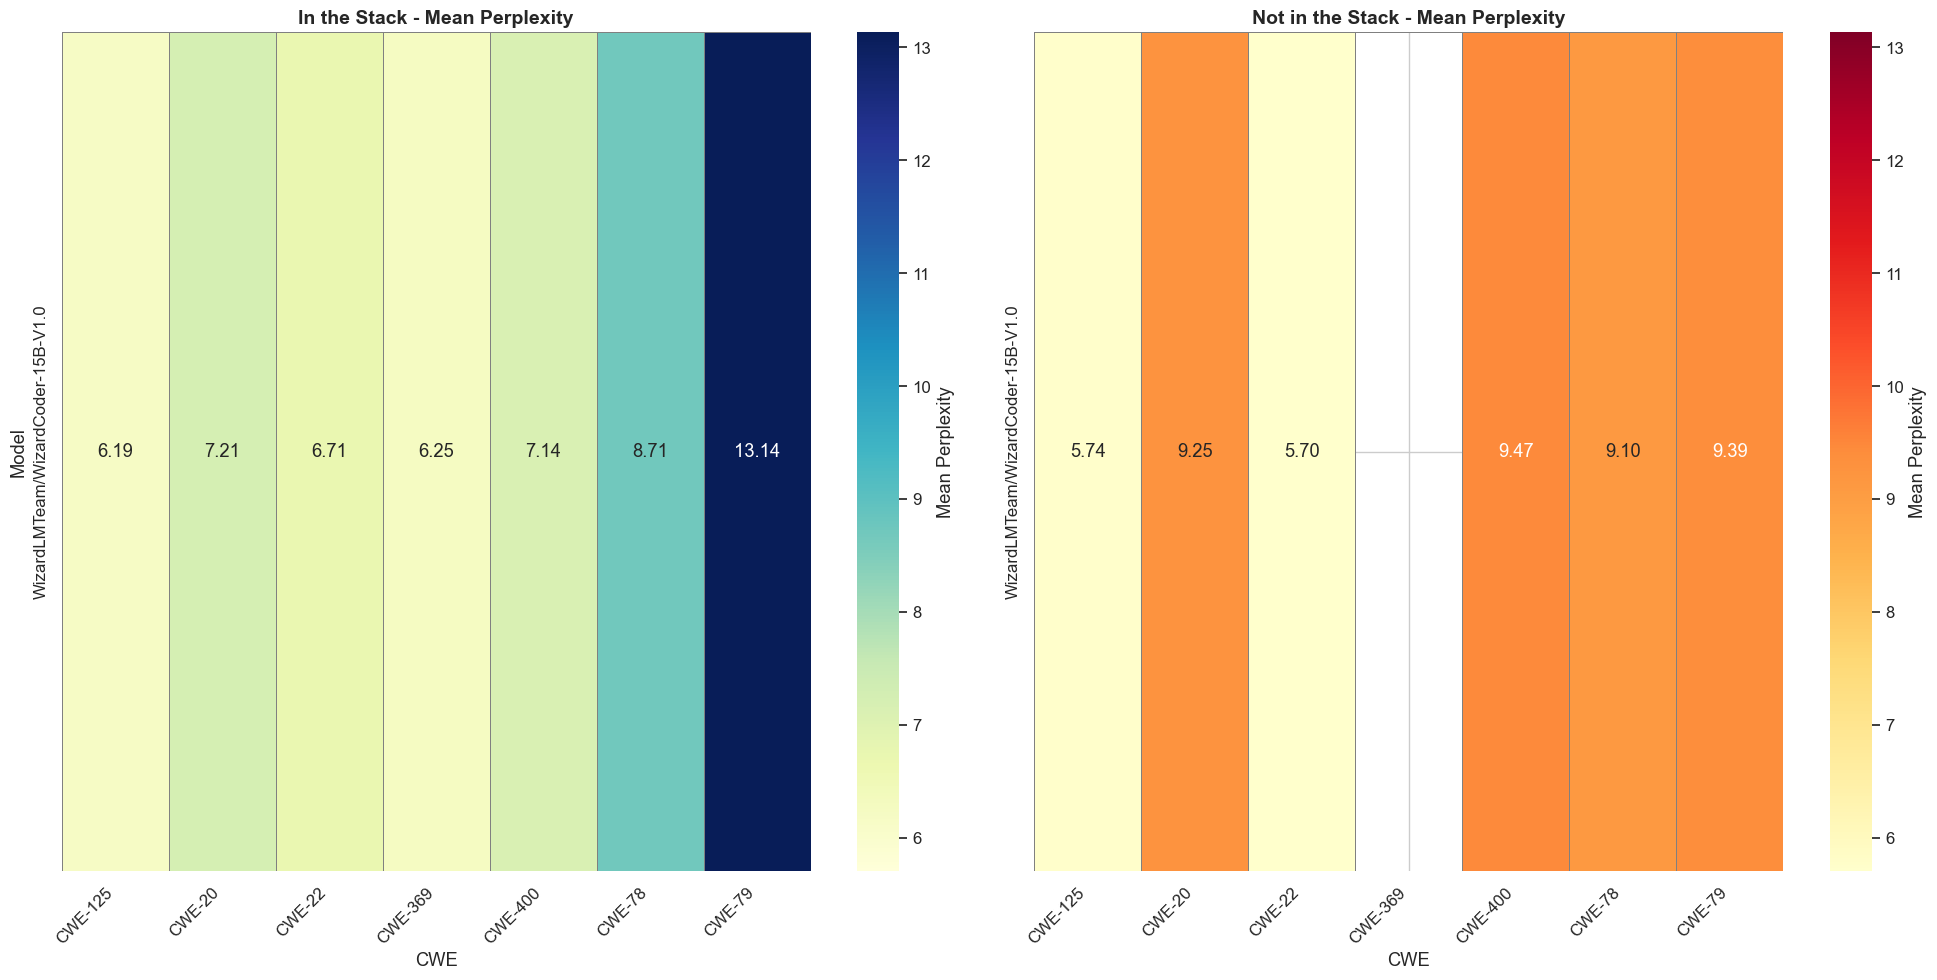

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filtered DataFrames
in_the_stack_df = filter_in_the_stack_snippets(non_patched_df, in_the_stack=True)
non_in_the_stack_df = filter_in_the_stack_snippets(non_patched_df, in_the_stack=False)

# Helper function to prepare pivot data
def prepare_pivot(df):
    mean_values = df.groupby(["model", "cwe"]).mean(numeric_only=True).reset_index()
    return mean_values.pivot(index="model", columns="cwe", values="mean")

# Prepare pivot tables
pivot_in_stack = prepare_pivot(in_the_stack_df)
pivot_not_in_stack = prepare_pivot(non_in_the_stack_df)

# Get union of all columns (CWEs) and rows (models)
all_cwes = sorted(set(pivot_in_stack.columns).union(pivot_not_in_stack.columns))
all_models = sorted(set(pivot_in_stack.index).union(pivot_not_in_stack.index))

# Reindex both pivot tables to ensure same shape and ordering
pivot_in_stack = pivot_in_stack.reindex(index=all_models, columns=all_cwes)
pivot_not_in_stack = pivot_not_in_stack.reindex(index=all_models, columns=all_cwes)

# Plot settings
plt.figure(figsize=(20, 10))
sns.set(font_scale=1.1)
sns.set_style("whitegrid")

# Heatmap 1: In the Stack
plt.subplot(1, 2, 1)
sns.heatmap(
    pivot_in_stack,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Mean Perplexity'},
    vmin=min(pivot_in_stack.min().min(), pivot_not_in_stack.min().min()),
    vmax=max(pivot_in_stack.max().max(), pivot_not_in_stack.max().max())
)
plt.title("In the Stack - Mean Perplexity", fontsize=14, weight='bold')
plt.xlabel("CWE")
plt.ylabel("Model")
plt.xticks(rotation=45, ha='right')

# Heatmap 2: Not In the Stack
plt.subplot(1, 2, 2)
sns.heatmap(
    pivot_not_in_stack,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Mean Perplexity'},
    vmin=min(pivot_in_stack.min().min(), pivot_not_in_stack.min().min()),
    vmax=max(pivot_in_stack.max().max(), pivot_not_in_stack.max().max())
)
plt.title("Not in the Stack - Mean Perplexity", fontsize=14, weight='bold')
plt.xlabel("CWE")
plt.ylabel("")

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## Perplexity Diff with Familiarity Analysis

In [28]:
# for each cwe and model, compute the diff in perplexity for the cwe and the patched cwe
# and store it in a new column called diff

unique_models = df['model'].unique()
cwes = df['cwe'].unique()
cwes = [cwe for cwe in cwes if "Patched" not in cwe]

test_df = df.copy()
# make it a list in every row for the column "diff"
test_df["diff"] = test_df["perplexity"].apply(lambda x: [0] * len(x))
for i, row in test_df.iterrows():
    # for each model, compute the diff in perplexity for the cwe and the patched cwe
    if row["cwe"] in cwes and row["model"] in unique_models:
        # get the patched cwe
        patched_cwe = row["cwe"] + " Patched"
        # get the perplexity for the cwe and the patched cwe
        cwe_perplexity = test_df[(test_df["cwe"] == row["cwe"]) & (test_df["model"] == row["model"])]["perplexity"].values[0]
        patched_cwe_perplexity = test_df[(test_df["cwe"] == patched_cwe) & (test_df["model"] == row["model"])]["perplexity"].values[0]
        # compute the diff
        diff = cwe_perplexity - patched_cwe_perplexity
        # store the diff in the new column
        test_df.at[i, "diff"] = diff
    else:
        # if the cwe is not in the list, set the diff to 0
        test_df.at[i, "diff"] = 0


diff_df = test_df[~test_df["cwe"].str.contains("Patched")]
# Apply filter
diff_in_the_stack_df = filter_in_the_stack_snippets(diff_df, in_the_stack=True, has_diff_column=True)
diff_non_in_the_stack_df = filter_in_the_stack_snippets(diff_df, in_the_stack=False, has_diff_column=True)

In [29]:
diff_in_the_stack_df.shape, diff_non_in_the_stack_df.shape

((7, 17), (6, 17))

In [30]:
# Plot the 4 quadrants of:
# 1. In the Stack and Diff > 0
# 2. In the Stack and Diff < 0
# 3. Not In the Stack and Diff > 0
# 4. Not In the Stack and Diff < 0


# Flatten the DataFrames
def flatten_snippets(df):
    flattened_rows = []
    for _, row in df.iterrows():
        for j, snippet in enumerate(row["snippets"]):
            flattened_rows.append({
                "model": row["model"],
                "cwe": row["cwe"],
                "diff": row["diff"][j],
                "perplexity": row["perplexity"][j],
                "snippet": snippet,
                "vuln_id": row["vuln_ids"][j],
                "published_date": row["published_dates"][j],
                "commit_href": row["commit_hrefs"][j],
                "score": row["scores"][j],
                "additions": row["additions"][j],
                "deletions": row["deletions"][j],
                "in_the_stack": row["in_the_stack"][j]
            })
    return pd.DataFrame(flattened_rows)
flattened_in_the_stack_df = flatten_snippets(diff_in_the_stack_df)
flattened_non_in_the_stack_df = flatten_snippets(diff_non_in_the_stack_df)
flattened_in_the_stack_df.head(1)
flattened_non_in_the_stack_df.head(1)

# Combine the two DataFrames
combined_df = pd.concat([flattened_in_the_stack_df, flattened_non_in_the_stack_df], ignore_index=True)



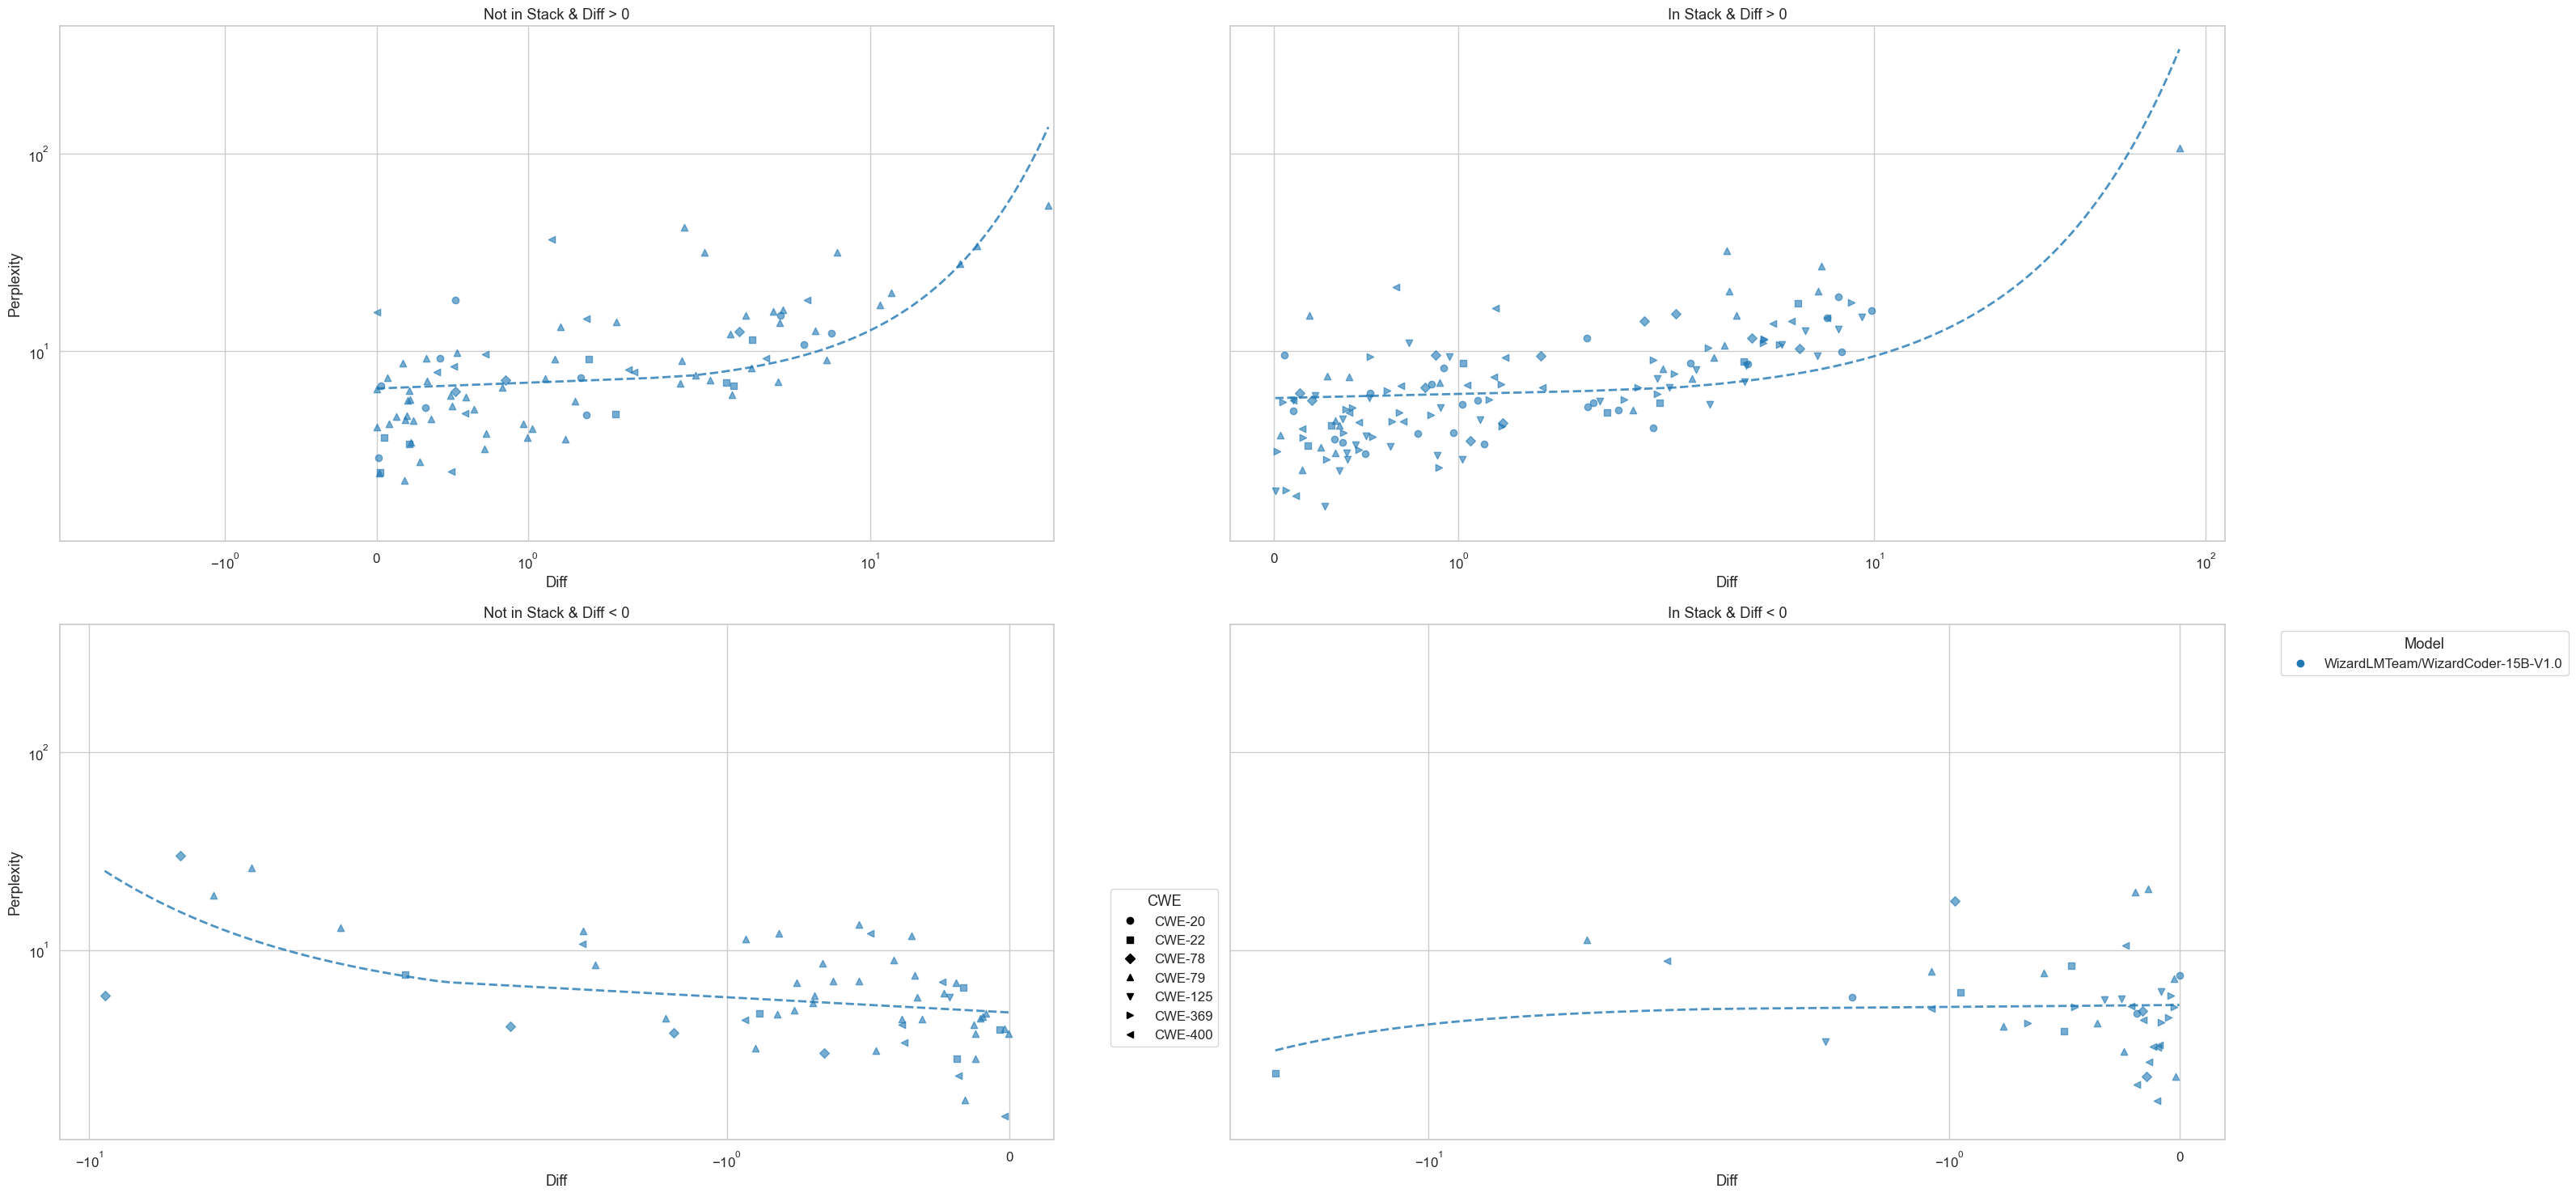

In [31]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.lines as mlines
import numpy as np

def plot_quadrants(df):
    fig, axes = plt.subplots(2, 2, figsize=(32, 15), sharey=True)
    axes = axes.flatten()

    # Define the 4 combinations
    quadrants = [
        (False, True),    # Not in stack & diff > 0
        (True, True),    # In stack & diff > 0
        (False, False),  # Not in stack & diff < 0
         (True, False),   # In stack & diff < 0
    ]

    titles = [
        "Not in Stack & Diff > 0",
        "In Stack & Diff > 0",
        "Not in Stack & Diff < 0",
        "In Stack & Diff < 0",
    ]

    # Generate distinct colors for each model
    models = df['model'].unique()
    colors = dict(zip(models, cm.tab20(np.linspace(0, 1, len(models)))))

    # Define distinct markers for CWEs (cycle if needed)
    markers_list = ['o', 's', 'D', '^', 'v', '>', '<', 'p', '*', 'X', 'H', 'd']
    cwes = df['cwe'].unique()
    marker_map = {cwe: markers_list[i % len(markers_list)] for i, cwe in enumerate(cwes)}

    for ax, key, title in zip(axes, quadrants, titles):
        group = df[(df["in_the_stack"] == key[0]) & ((df["diff"] > 0) == key[1])]


        # Plot each point with model color and CWE marker
        for model in group['model'].unique():
            for cwe in group['cwe'].unique():
                sub_group = group[(group['model'] == model) & (group['cwe'] == cwe)]
                if sub_group.empty:
                    continue
                color = colors[model]
                marker = marker_map[cwe]
                ax.scatter(sub_group["diff"], sub_group["perplexity"],
                           color=color, marker=marker, alpha=0.6)

            # Fit regression line for model (only if at least 2 points and y > 0)
            model_group = group[group['model'] == model]
            x = model_group['diff']
            y = model_group['perplexity']
            if len(model_group) >= 2 and (y > 0).all():
                coeffs = np.polyfit(x, np.log(y), deg=1)
                x_fit = np.linspace(x.min(), x.max(), 100)
                y_fit = np.exp(coeffs[0] * x_fit + coeffs[1])
                ax.plot(x_fit, y_fit, color=colors[model], alpha=0.8, linewidth=2, linestyle='--')



        # for _, row in group.iterrows():
        #     color = colors[row['model']]
        #     marker = marker_map[row['cwe']]
        #     ax.scatter(row["diff"], row["perplexity"], color=color, marker=marker, alpha=0.6)

        ax.set_title(title)
        ax.set_xlabel("Diff")
        ax.set_yscale("log")
        ax.set_xscale("symlog")
        ax.grid(True)

    axes[0].set_ylabel("Perplexity")
    axes[2].set_ylabel("Perplexity")

    # Create legends
    model_legend = [mlines.Line2D([], [], color=color, marker='o', linestyle='None', label=model)
                    for model, color in colors.items()]
    cwe_legend = [mlines.Line2D([], [], color='black', marker=marker, linestyle='None', label=cwe)
                  for cwe, marker in marker_map.items()]

    # Place legends outside the plot
    axes[-1].legend(handles=model_legend, title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[-2].legend(handles=cwe_legend, title="CWE", bbox_to_anchor=(1.05, 0.5), loc='upper left')

    plt.tight_layout()
    plt.show()
plot_quadrants(combined_df)

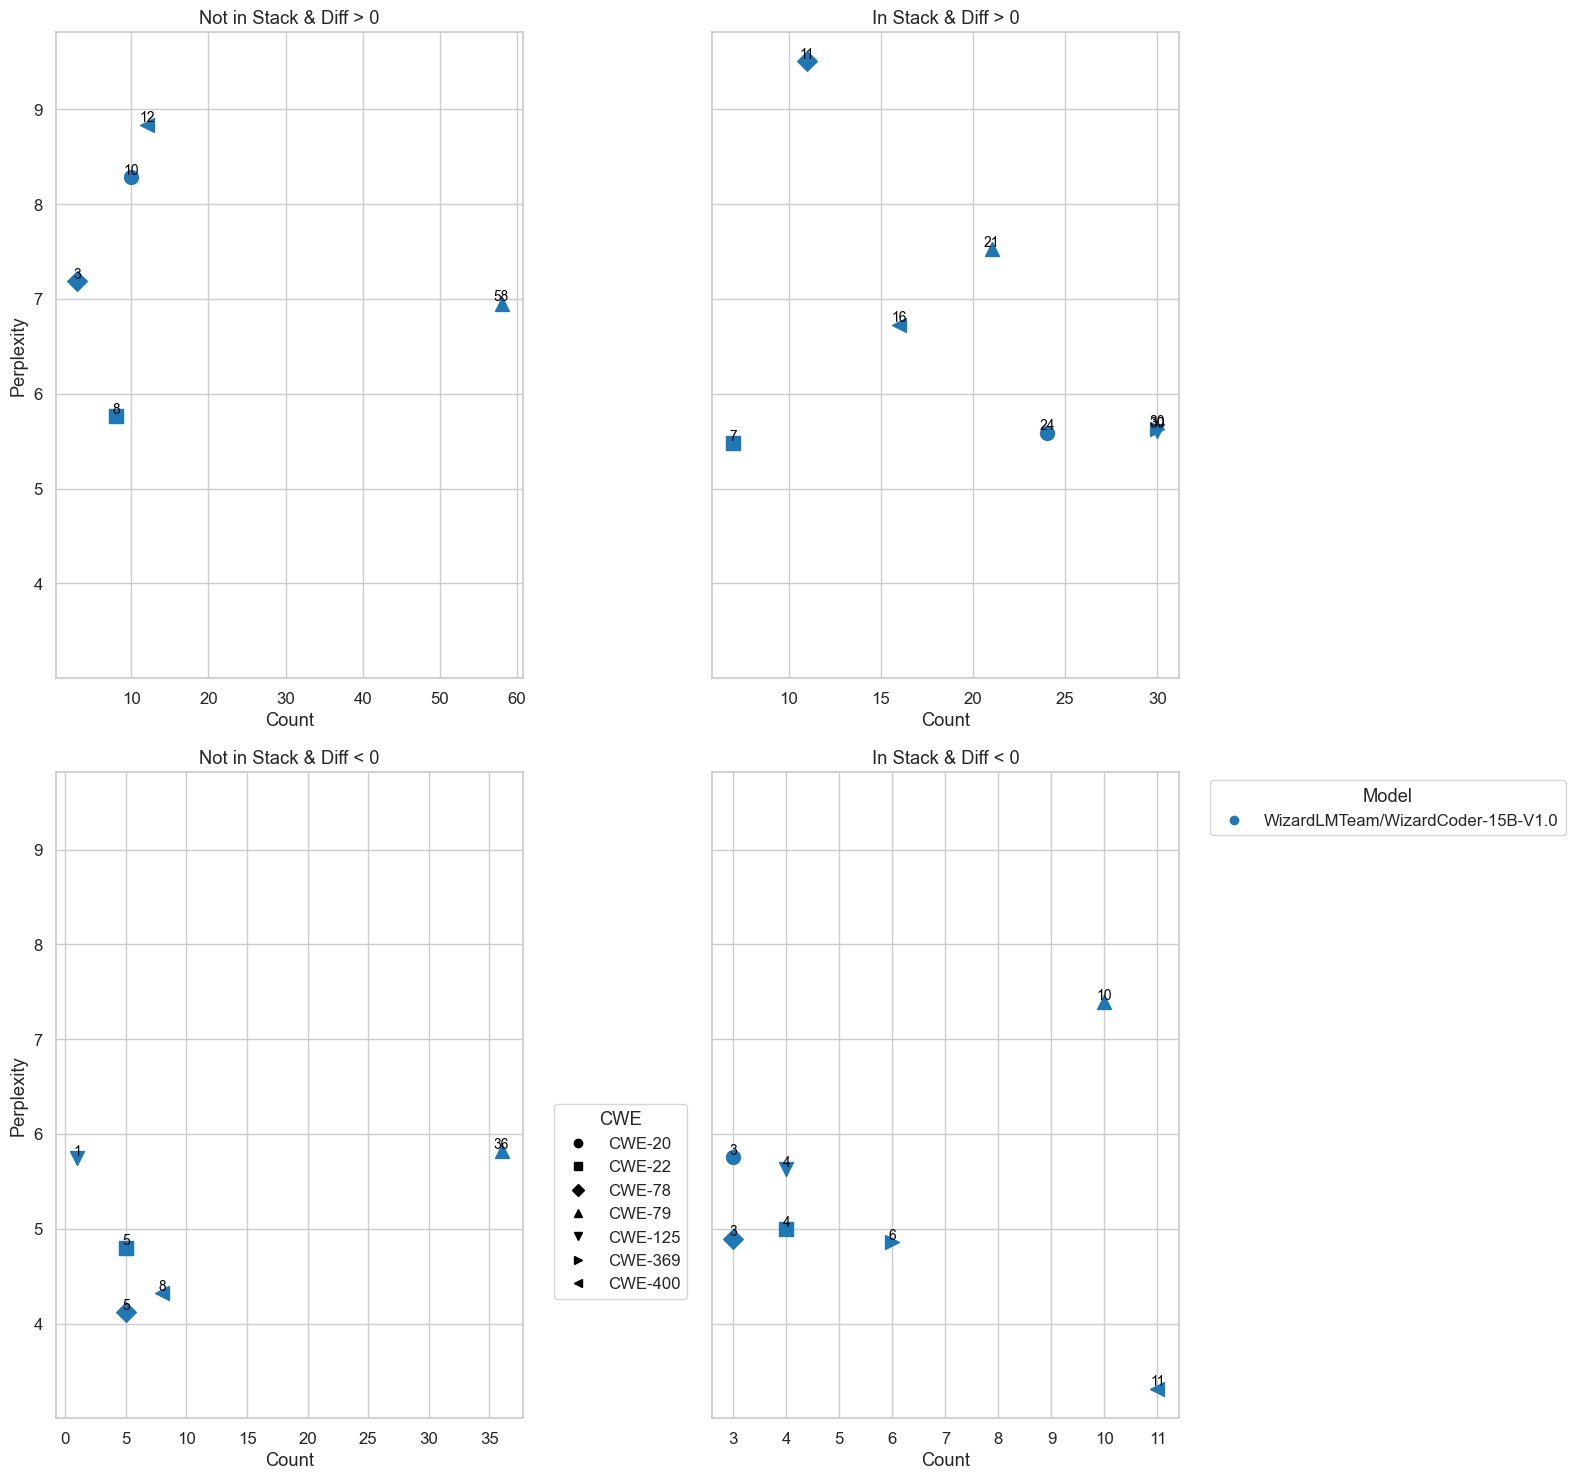

In [32]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.lines as mlines
import numpy as np

def plot_quadrants_count(df):
    fig, axes = plt.subplots(2, 2, figsize=(16, 15), sharey=True)
    axes = axes.flatten()

    quadrants = [
        (False, True),    # Not in stack & diff > 0
        (True, True),     # In stack & diff > 0
        (False, False),   # Not in stack & diff < 0
        (True, False),    # In stack & diff < 0
    ]

    titles = [
        "Not in Stack & Diff > 0",
        "In Stack & Diff > 0",
        "Not in Stack & Diff < 0",
        "In Stack & Diff < 0",
    ]

    models = df['model'].unique()
    colors = dict(zip(models, cm.tab20(np.linspace(0, 1, len(models)))))

    markers_list = ['o', 's', 'D', '^', 'v', '>', '<', 'p', '*', 'X', 'H', 'd']
    cwes = df['cwe'].unique()
    marker_map = {cwe: markers_list[i % len(markers_list)] for i, cwe in enumerate(cwes)}

    for ax, key, title in zip(axes, quadrants, titles):
        ax.set_title(title)
        group = df[(df["in_the_stack"] == key[0]) & ((df["diff"] > 0) == key[1])]

        # Count and median
        counts = group.groupby(['model', 'cwe']).size().reset_index(name='count')
        median_values = group.groupby(['model', 'cwe'])['perplexity'].median().reset_index(name='median')

        merged = pd.merge(counts, median_values, on=['model', 'cwe'])

        for _, row in merged.iterrows():
            model = row['model']
            cwe = row['cwe']
            count = row['count']
            median = row['median']

            ax.scatter(count, median, 
                       color=colors[model], 
                       marker=marker_map[cwe], 
                       s=100, label=f'{model}-{cwe}')

            ax.text(count, median, str(count), fontsize=10, ha='center', va='bottom', color='black')

        ax.set_xlabel("Count")
        ax.grid(True)

    axes[0].set_ylabel("Perplexity")
    axes[2].set_ylabel("Perplexity")

    # Legends
    model_legend = [mlines.Line2D([], [], color=color, marker='o', linestyle='None', label=model)
                    for model, color in colors.items()]
    cwe_legend = [mlines.Line2D([], [], color='black', marker=marker, linestyle='None', label=cwe)
                  for cwe, marker in marker_map.items()]

    axes[-1].legend(handles=model_legend, title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[-2].legend(handles=cwe_legend, title="CWE", bbox_to_anchor=(1.05, 0.5), loc='upper left')

    plt.tight_layout()
    plt.show()


plot_quadrants_count(combined_df)

/var/folders/b4/lwfgccm95kqd2skcwvrt2fr00000gn/T/ipykernel_60980/2330708060.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/b4/lwfgccm95kqd2skcwvrt2fr00000gn/T/ipykernel_60980/2330708060.py:61: UserWarning: Glyph 8743 (\N{LOGICAL AND}) missing from font(s) Arial.
  plt.tight_layout()
/Users/ruimelo/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8743 (\N{LOGICAL AND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


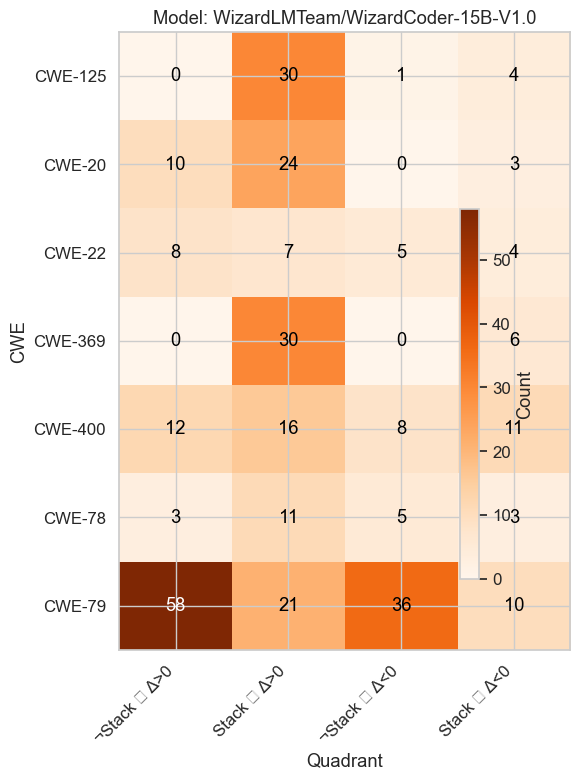

In [33]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd

def plot_model_quadrant_heatmaps(df):
    models = df['model'].unique()
    cwes = sorted(df['cwe'].unique())

    quadrant_labels = [
        "¬Stack ∧ Δ>0",  # False, True
        "Stack ∧ Δ>0",   # True, True
        "¬Stack ∧ Δ<0",  # False, False
        "Stack ∧ Δ<0",   # True, False
    ]

    # Map quadrants to indices
    quadrant_conditions = [
        (False, True),
        (True, True),
        (False, False),
        (True, False),
    ]

    n_models = len(models)
    fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 8), sharey=True)

    if n_models == 1:
        axes = [axes]  # Ensure it's iterable

    for ax, model in zip(axes, models):
        model_df = df[df['model'] == model]

        # Create a matrix (CWE x quadrant)
        heatmap_data = np.zeros((len(cwes), 4), dtype=int)

        for q_idx, (in_stack, diff_positive) in enumerate(quadrant_conditions):
            group = model_df[(model_df["in_the_stack"] == in_stack) & ((model_df["diff"] > 0) == diff_positive)]
            counts = group['cwe'].value_counts()
            for cwe_idx, cwe in enumerate(cwes):
                heatmap_data[cwe_idx, q_idx] = counts.get(cwe, 0)

        im = ax.imshow(heatmap_data, cmap='Oranges', aspect='auto')

        ax.set_xticks(np.arange(4))
        ax.set_xticklabels(quadrant_labels, rotation=45, ha='right')
        ax.set_yticks(np.arange(len(cwes)))
        ax.set_yticklabels(cwes)
        ax.set_title(f"Model: {model}")
        ax.set_xlabel("Quadrant")
        ax.set_ylabel("CWE")

        # Annotate each cell
        for i in range(len(cwes)):
            for j in range(4):
                ax.text(j, i, str(heatmap_data[i, j]),
                        ha='center', va='center',
                        color='black' if heatmap_data[i, j] < heatmap_data.max() / 1.5 else 'white')

    fig.colorbar(im, ax=axes, location='right', shrink=0.6, label='Count')
    plt.tight_layout()
    plt.show()

plot_model_quadrant_heatmaps(combined_df)

/var/folders/b4/lwfgccm95kqd2skcwvrt2fr00000gn/T/ipykernel_60980/2158669489.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


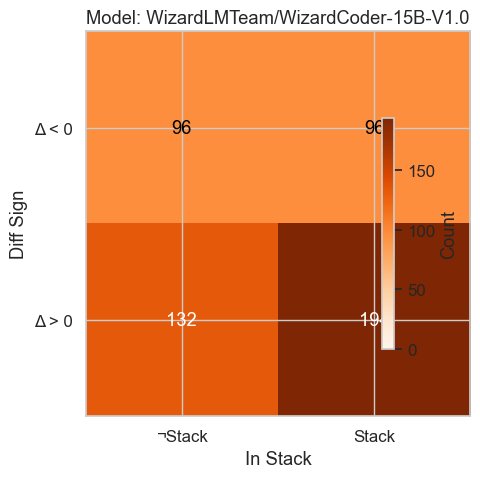

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_2x2_heatmap_per_model_swapped(df):
    models = sorted(df['model'].unique())
    n_models = len(models)

    fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5))

    if n_models == 1:
        axes = [axes]  # Ensure iterable

    for ax, model in zip(axes, models):
        model_df = df[df['model'] == model]

        # Initialize a 2x2 matrix (diff > 0: rows, in_the_stack: columns)
        heatmap_data = np.zeros((2, 2), dtype=int)

        for i, diff_positive in enumerate([False, True]):
            for j, in_stack in enumerate([False, True]):
                count = len(model_df[(model_df["diff"] > 0) == diff_positive & (model_df["in_the_stack"] == in_stack)])
                heatmap_data[i, j] = count

        im = ax.imshow(heatmap_data, cmap='Oranges', vmin=0, aspect='equal')

        ax.set_title(f"Model: {model}")
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["¬Stack", "Stack"])
        ax.set_yticks([0, 1])
        ax.set_yticklabels(["Δ < 0", "Δ > 0"])
        ax.set_xlabel("In Stack")
        ax.set_ylabel("Diff Sign")

        # Annotate each cell
        for i in range(2):
            for j in range(2):
                count = heatmap_data[i, j]
                ax.text(j, i, str(count), ha='center', va='center',
                        color='black' if count < heatmap_data.max() / 1.5 else 'white')

    fig.colorbar(im, ax=axes, shrink=0.6, label='Count')
    plt.tight_layout()
    plt.show()

plot_2x2_heatmap_per_model_swapped(combined_df)

/var/folders/b4/lwfgccm95kqd2skcwvrt2fr00000gn/T/ipykernel_60980/3362554642.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


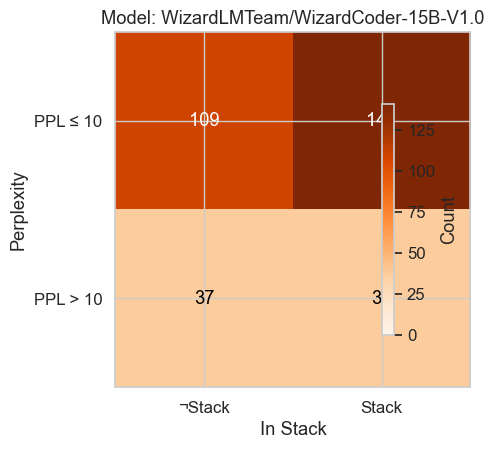

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PPL_THRESHOLD = 10

def plot_2x2_heatmap_per_model_swapped(df):
    models = sorted(df['model'].unique())
    n_models = len(models)

    fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5))

    if n_models == 1:
        axes = [axes]  # Ensure iterable

    for ax, model in zip(axes, models):
        model_df = df[df['model'] == model]

        # Initialize a 2x2 matrix (perplexity > threshold: rows, in_the_stack: columns)
        heatmap_data = np.zeros((2, 2), dtype=int)

        for i, perplexity_high in enumerate([False, True]):
            for j, in_stack in enumerate([False, True]):
                count = len(model_df[
                    ((model_df["perplexity"] > PPL_THRESHOLD) == perplexity_high) &
                    (model_df["in_the_stack"] == in_stack)
                ])
                heatmap_data[i, j] = count

        # Create the heatmap
        im = ax.imshow(heatmap_data, cmap='Oranges', vmin=0, aspect='equal')

        ax.set_title(f"Model: {model}")
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["¬Stack", "Stack"])
        ax.set_yticks([0, 1])
        ax.set_yticklabels([f"PPL ≤ {PPL_THRESHOLD}", f"PPL > {PPL_THRESHOLD}"])
        ax.set_xlabel("In Stack")
        ax.set_ylabel("Perplexity")

        # Annotate each cell
        for i in range(2):
            for j in range(2):
                count = heatmap_data[i, j]
                ax.text(j, i, str(count), ha='center', va='center',
                        color='black' if count < heatmap_data.max() / 1.5 else 'white')

    fig.colorbar(im, ax=axes, shrink=0.6, label='Count')
    plt.tight_layout()
    plt.show()

# Example usage
# Drop repeated "snippet" per model
combined_df = combined_df.drop_duplicates(subset=["model", "snippet"])


plot_2x2_heatmap_per_model_swapped(combined_df)


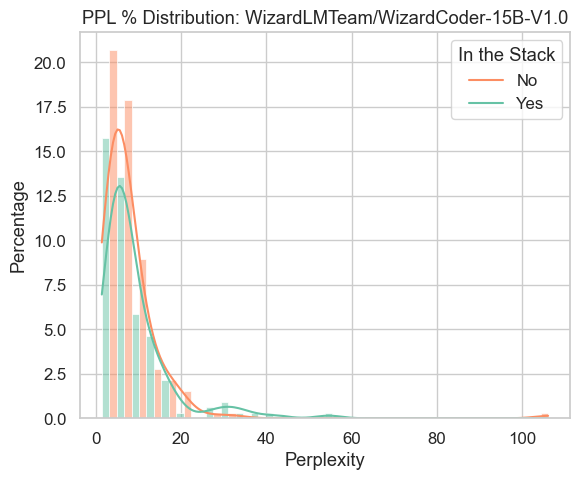

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_ppl_percentage_distribution_by_stack(df, log_scale=False):
    models = sorted(df['model'].unique())
    n_models = len(models)

    fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5), sharey=True)

    if n_models == 1:
        axes = [axes]  # Ensure iterable

    for ax, model in zip(axes, models):
        model_df = df[df['model'] == model]

        sns.histplot(
            data=model_df,
            x='perplexity',
            hue='in_the_stack',
            kde=True,
            stat='percent',
            bins=30,
            ax=ax,
            palette='Set2',
            multiple='dodge'
        )

        ax.set_title(f"PPL % Distribution: {model}")
        ax.set_xlabel("Perplexity")
        ax.set_ylabel("Percentage")
        ax.legend(title="In the Stack", labels=["No", "Yes"])

        if log_scale:
            ax.set_xscale('log')
            ax.set_xlabel("Perplexity (log scale)")

    plt.tight_layout()
    plt.show()

# Usage
# combined_df = combined_df.drop_duplicates(subset=["model", "snippet"])
plot_ppl_percentage_distribution_by_stack(combined_df, log_scale=False)


## Radar Chart for all the Vulnerabilities (not including Patched versions)


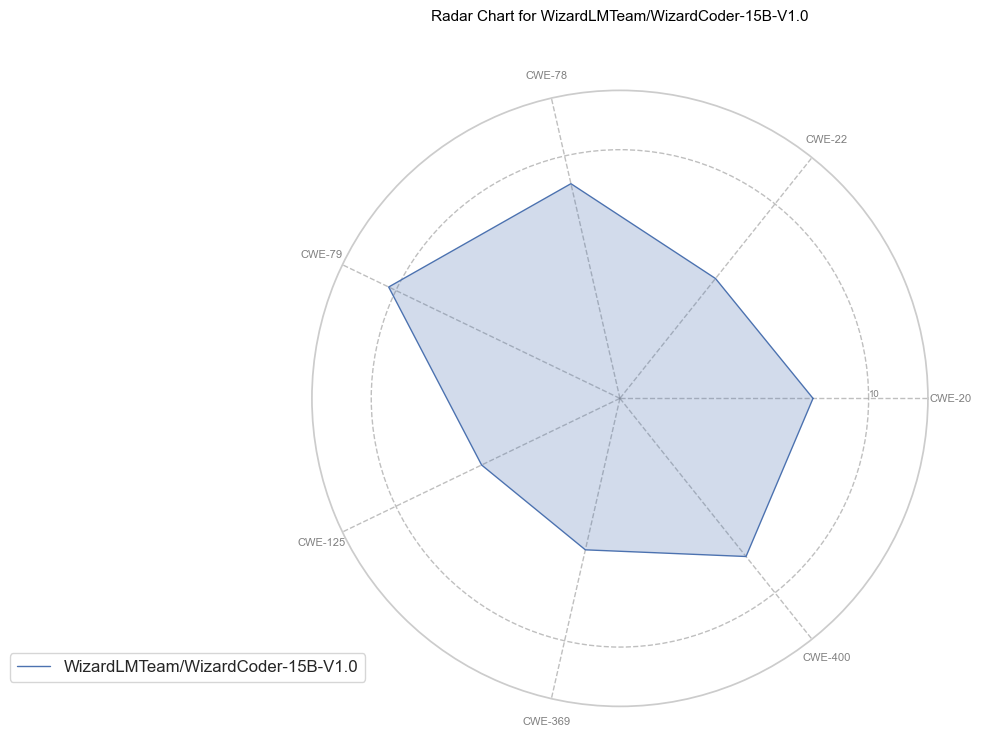

In [37]:
import matplotlib.pyplot as plt
import numpy as np

non_patched_df = df[~df["cwe"].str.contains("Patched")]

# Get unique CWEs
unique_cwes = non_patched_df["cwe"].unique()

# Get unique models
unique_models = non_patched_df["model"].unique()

# for each model, create a different radar plot where each cwe is a different axis
for model in unique_models:
    # Get the data for this model
    model_df = non_patched_df[non_patched_df["model"] == model]

    # Get the number of CWEs
    num_cwes = len(model_df["cwe"].unique())

    # Create a radar chart
    angles = np.linspace(0, 2 * np.pi, num_cwes, endpoint=False).tolist()

    # The plot is circular, so we need to "complete the loop" and append the start to the end.
    values = model_df["mean"].tolist()
    values += values[:1]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    # Draw one axe per variable and add labels
    plt.xticks(angles[:-1], model_df["cwe"].tolist(), color='grey', size=8)

    # Draw ylabels
    ax.set_rlabel_position(0)
    plt.yticks([10, 20, 30, 40], ["10", "20", "30", "40"], color="grey", size=7)

    plt.ylim(0, max(values) * 1.2)

    # Enable grid lines
    ax.grid(True)  # Enables grid lines
    ax.yaxis.grid(True, linestyle='--', color='grey', alpha=0.5)  # Customize radial grid
    ax.xaxis.grid(True, linestyle='--', color='grey', alpha=0.5)  # Customize angular grid

    # Plot data
    ax.plot(angles, values, linewidth=1, linestyle='solid', label=model)

    # Fill area
    ax.fill(angles, values, alpha=0.25)

    plt.title(f'Radar Chart for {model}', size=11, color='black', y=1.1)
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))

    plt.show()


## Tags

In [38]:
cwe_tags = {
    "Injection Flaws": [
        "CWE-77", "CWE-78", "CWE-89", "CWE-94", "CWE-95", "CWE-116",
        "CWE-74", "CWE-79", "CWE-93"
    ],
    "Authentication Issues": [
        "CWE-287", "CWE-306", "CWE-798", "CWE-259",
        "CWE-255", "CWE-290", "CWE-307", "CWE-288", "CWE-294"
    ],
    "Authorization / Access Control": [
        "CWE-284", "CWE-285", "CWE-863", "CWE-732",
        "CWE-264", "CWE-275", "CWE-281", "CWE-639", "CWE-862"
    ],
    "Input Validation": [
        "CWE-20", "CWE-601", "CWE-134", "CWE-643",
        "CWE-129", "CWE-172", "CWE-682", "CWE-704", "CWE-707", "CWE-697"
    ],
    "File Handling": [
        "CWE-22", "CWE-73", "CWE-434", "CWE-97",
        "CWE-59", "CWE-61", "CWE-552"
    ],
    "Memory Management": [
        "CWE-119", "CWE-125", "CWE-787", "CWE-416",
        "CWE-120", "CWE-121", "CWE-122", "CWE-131", "CWE-401", "CWE-415", "CWE-417", "CWE-665", "CWE-667", "CWE-674", "CWE-763", "CWE-772"
    ],
    "Cryptography Issues": [
        "CWE-327", "CWE-328", "CWE-326", "CWE-311",
        "CWE-310", "CWE-320", "CWE-331"
    ],
    "Configuration": [
        "CWE-16", "CWE-250", "CWE-276", "CWE-269",
        "CWE-17", "CWE-19", "CWE-273", "CWE-924"
    ],
    "Error Handling / Logging": [
        "CWE-209", "CWE-248", "CWE-252",
        "CWE-388", "CWE-703", "CWE-704", "CWE-617", "CWE-532"
    ],
    "Information Disclosure": [
        "CWE-200", "CWE-201", "CWE-203",
        "CWE-212", "CWE-522", "CWE-613", "CWE-668", "CWE-918"
    ],
    "Denial of Service": [
        "CWE-400", "CWE-404", "CWE-770",
        "CWE-362", "CWE-369", "CWE-834", "CWE-835", "CWE-672"
    ],
    "Code Quality": [
        "CWE-561", "CWE-398", "CWE-563",
        "CWE-241", "CWE-254", "CWE-345", "CWE-346", "CWE-347", "CWE-354", "CWE-681", "CWE-682", "CWE-706", "CWE-754", "CWE-755"
    ],
    "Race Conditions / Concurrency": [
        "CWE-362", "CWE-361", "CWE-667", "CWE-663", "CWE-662"
    ],
    "Serialization / Deserialization": [
        "CWE-502"
    ],
    "XXE / XML Issues": [
        "CWE-611"
    ],
    "Security Misconfiguration": [
        "CWE-459", "CWE-565", "CWE-843", "CWE-909", "CWE-1021"
    ],
    "Unvalidated Redirects / CSRF": [
        "CWE-352"
    ],
    "Improper Certificate Validation": [
        "CWE-295", "CWE-346", "CWE-347"
    ],
    "Miscellaneous / Logic Issues": [
        "CWE-190", "CWE-191", "CWE-189", "CWE-193", "CWE-706", "CWE-664", "CWE-670", "CWE-843"
    ],
    "Object Injection / Insecure Deserialization": [
        "CWE-502"
    ],
    "Hardcoded Secrets / Weak Passwords": [
        "CWE-259", "CWE-798"
    ],
    "Improper Resource Access or Exposure": [
        "CWE-668", "CWE-552", "CWE-524", "CWE-918"
    ]
}


cwe_tags.setdefault("Authentication Issues", []).append("CWE-294")
cwe_tags.setdefault("Memory Management", []).extend(["CWE-399", "CWE-476", "CWE-824"])
cwe_tags.setdefault("Injection Flaws", []).append("CWE-444")
cwe_tags.setdefault("Resource Management", []).append("CWE-908")

In [39]:
df_cwe_tags = df.copy()
df_cwe_tags["cwe_tag"] = "Other"
# Assign CWE tags
for row in df_cwe_tags.itertuples():
    ends_with_patched = row.cwe.endswith(" Patched")
    row_cwe = row.cwe.split()[0] if row.cwe.endswith(" Patched") else row.cwe
    for tag, cwe_list in cwe_tags.items():
        if row_cwe in cwe_list:
            tag = tag if not ends_with_patched else tag + " Patched"
            df_cwe_tags.at[row.Index, "cwe_tag"] = tag 
            break

print(df_cwe_tags["cwe_tag"].value_counts())    

cwe_tag
Injection Flaws              2
Injection Flaws Patched      2
Denial of Service            2
Denial of Service Patched    2
Input Validation             1
Input Validation Patched     1
File Handling                1
File Handling Patched        1
Memory Management            1
Memory Management Patched    1
Name: count, dtype: int64


In [40]:
# group by cwe_tag and model
grouped_df = df_cwe_tags.groupby(["cwe_tag", "model"]).agg({
    "perplexity": lambda x: x.tolist()
}).reset_index()
grouped_df["perplexity"] = grouped_df["perplexity"].apply(lambda x: [float(item) for sublist in x for item in sublist if item > 0])

# Compute the IQR
grouped_df["iqr"] = grouped_df["perplexity"].apply(lambda x: np.percentile(x, 75) - np.percentile(x, 25))

# Compute the mean
grouped_df["mean"] = grouped_df["perplexity"].apply(lambda x: np.mean(x))

# Compute the median
grouped_df["median"] = grouped_df["perplexity"].apply(lambda x: np.median(x))

grouped_df

,cwe_tag,model,perplexity,iqr,mean,median
0,Denial of Service,WizardLMTeam/WizardCoder-15B-V1.0,"[6.819545269012451, 4.415157318115234, 5.13764...",5.071763,7.314414,5.640239
1,Denial of Service Patched,WizardLMTeam/WizardCoder-15B-V1.0,"[5.588657379150391, 3.7768044471740723, 5.5955...",3.253094,6.260732,5.185905
2,File Handling,WizardLMTeam/WizardCoder-15B-V1.0,"[8.680630683898926, 2.454801559448242, 8.89686...",3.859567,6.164584,5.199112
3,File Handling Patched,WizardLMTeam/WizardCoder-15B-V1.0,"[7.652802467346191, 2.4308886528015137, 4.8467...",4.420924,6.179814,4.208648
4,Injection Flaws,WizardLMTeam/WizardCoder-15B-V1.0,"[7.187116622924805, 5.85998010635376, 6.130472...",7.230262,10.101538,6.864848
5,Injection Flaws Patched,WizardLMTeam/WizardCoder-15B-V1.0,"[6.338003635406494, 15.181390762329102, 5.9902...",5.009032,8.122491,5.996842
6,Input Validation,WizardLMTeam/WizardCoder-15B-V1.0,"[5.676312446594238, 4.127105712890625, 16.1468...",4.775777,7.764019,6.148308
7,Input Validation Patched,WizardLMTeam/WizardCoder-15B-V1.0,"[4.570919036865234, 1.9771692752838135, 6.3466...",3.895571,5.667931,4.951563
8,Memory Management,WizardLMTeam/WizardCoder-15B-V1.0,"[5.810939311981201, 1.9709300994873047, 12.651...",4.278980,6.173496,5.640239
9,Memory Management Patched,WizardLMTeam/WizardCoder-15B-V1.0,"[5.295819282531738, 1.9643388986587524, 6.4522...",2.904115,4.364920,4.276109


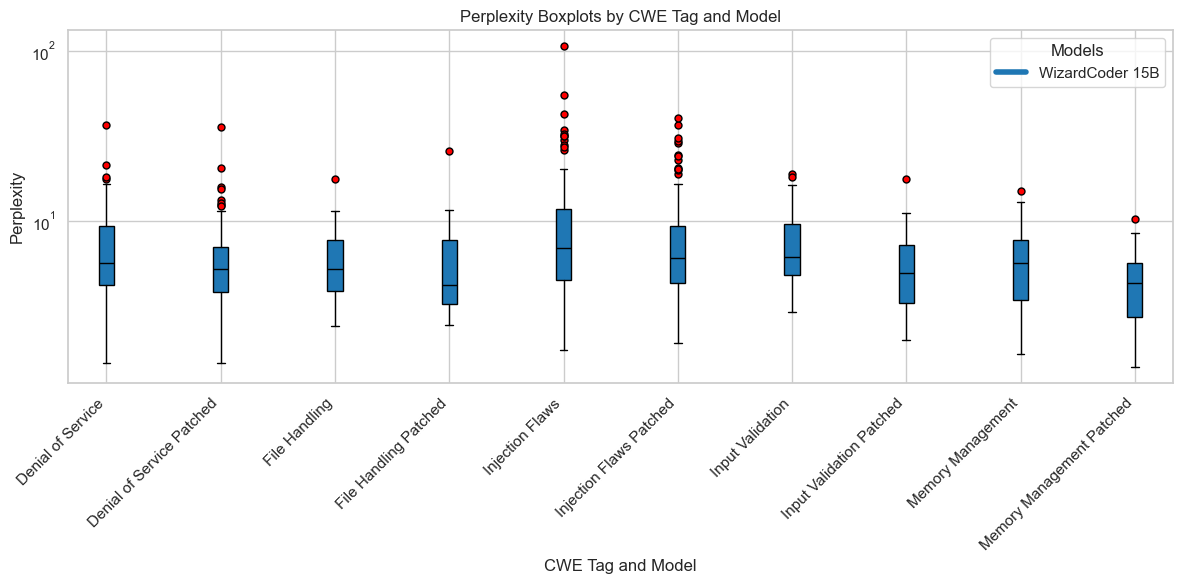

In [41]:
# Plot the grouped boxplots

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")


def plot_grouped_boxplots_tags(df, cwe_subset, model_colors):
    plt.figure(figsize=(12, 6))
    
    # Filter data for selected CWEs
    subset_df = df[df["cwe_tag"].isin(cwe_subset)]
    
    # Sort dataframe by CWE and model
    sorted_df = subset_df.sort_values(by=['cwe_tag', 'model'])
    
    positions = []
    labels = []
    idx = 0
    cwe_spacing = 1.5  # Control spacing between different CWEs
    model_spacing = 0.3  # Control spacing between models under the same CWE

    legend_handles = {}  # To store legend handles
    
    # Grouping by CWE
    for cwe in sorted_df["cwe_tag"].unique():
        cwe_df = sorted_df[sorted_df["cwe_tag"] == cwe]
        cwe_base_idx = idx
        
        for j, model in enumerate(cwe_df["model"].unique()):
            model_df = cwe_df[cwe_df["model"] == model]
            pos = cwe_base_idx + j * model_spacing
            
            # Create boxplot and capture its elements
            box = plt.boxplot(
                model_df["perplexity"],
                positions=[pos],
                widths=0.2,
                patch_artist=True,
                medianprops=dict(color="black"),
                whiskerprops=dict(color="black"),
                capprops=dict(color="black"),
                flierprops=dict(marker="o", markersize=5, markerfacecolor="red"),
            )
            
            # Color the boxes appropriately
            for b in box['boxes']:
                b.set_facecolor(model_colors[model])

            # Store legend info
            if model not in legend_handles:
                legend_handles[model] = plt.Line2D([0], [0], color=model_colors[model], lw=4, label=prettier_names[model])

            if cwe not in labels:
                labels.append(cwe)
            else:
                labels.append("")
            positions.append(pos)
            
        # Update the index to keep CWEs close together
        idx = pos + cwe_spacing
    # Adjust x-axis labels
    plt.xticks(positions, labels, rotation=45, ha="right")
    plt.xlabel("CWE Tag and Model")
    plt.ylabel("Perplexity")
    plt.title("Perplexity Boxplots by CWE Tag and Model")
    plt.legend(handles=legend_handles.values(), title="Models")  # Add legend
    plt.tight_layout()
    plt.yscale("log")
    plt.show()

# Get unique CWE values
unique_cwes = grouped_df["cwe_tag"].unique()

# Assign colors to models
unique_models = grouped_df['model'].unique()
model_colors = {model: plt.cm.tab10(i % 10) for i, model in enumerate(unique_models)}

# Define batch size
batch_size = 10

# Generate plots in batches
for i in range(0, len(unique_cwes), batch_size):
    cwe_batch = unique_cwes[i:i+batch_size]
    plot_grouped_boxplots_tags(grouped_df, cwe_batch, model_colors)

In [42]:
grouped_df

,cwe_tag,model,perplexity,iqr,mean,median
0,Denial of Service,WizardLMTeam/WizardCoder-15B-V1.0,"[6.819545269012451, 4.415157318115234, 5.13764...",5.071763,7.314414,5.640239
1,Denial of Service Patched,WizardLMTeam/WizardCoder-15B-V1.0,"[5.588657379150391, 3.7768044471740723, 5.5955...",3.253094,6.260732,5.185905
2,File Handling,WizardLMTeam/WizardCoder-15B-V1.0,"[8.680630683898926, 2.454801559448242, 8.89686...",3.859567,6.164584,5.199112
3,File Handling Patched,WizardLMTeam/WizardCoder-15B-V1.0,"[7.652802467346191, 2.4308886528015137, 4.8467...",4.420924,6.179814,4.208648
4,Injection Flaws,WizardLMTeam/WizardCoder-15B-V1.0,"[7.187116622924805, 5.85998010635376, 6.130472...",7.230262,10.101538,6.864848
5,Injection Flaws Patched,WizardLMTeam/WizardCoder-15B-V1.0,"[6.338003635406494, 15.181390762329102, 5.9902...",5.009032,8.122491,5.996842
6,Input Validation,WizardLMTeam/WizardCoder-15B-V1.0,"[5.676312446594238, 4.127105712890625, 16.1468...",4.775777,7.764019,6.148308
7,Input Validation Patched,WizardLMTeam/WizardCoder-15B-V1.0,"[4.570919036865234, 1.9771692752838135, 6.3466...",3.895571,5.667931,4.951563
8,Memory Management,WizardLMTeam/WizardCoder-15B-V1.0,"[5.810939311981201, 1.9709300994873047, 12.651...",4.278980,6.173496,5.640239
9,Memory Management Patched,WizardLMTeam/WizardCoder-15B-V1.0,"[5.295819282531738, 1.9643388986587524, 6.4522...",2.904115,4.364920,4.276109


In [43]:
# Remove the "Other" tag from grouped_df
grouped_df = grouped_df[grouped_df["cwe_tag"] != "Other"]

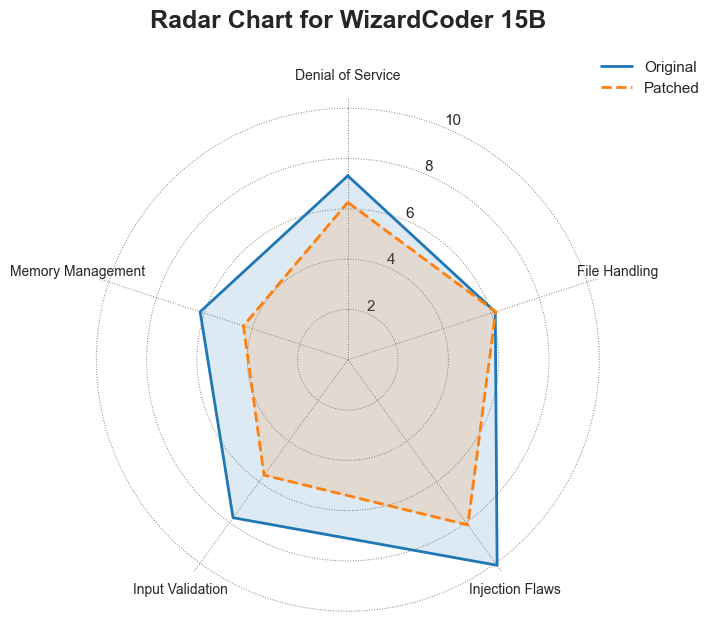

In [44]:
import matplotlib.pyplot as plt
import numpy as np

# Normalize CWE tags
grouped_df['base_cwe'] = grouped_df['cwe_tag'].str.replace(' Patched', '', regex=False)
grouped_df['patched'] = grouped_df['cwe_tag'].str.contains('Patched')

# Base tags and models
base_tags = grouped_df['base_cwe'].unique()
models = grouped_df['model'].unique()

# Radar chart setup
num_vars = len(base_tags)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

# Style settings
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 18,
    'legend.fontsize': 11,
})

# Color palette
colors = {
    'Original': '#1f77b4',  # Blue
    'Patched': '#ff7f0e'    # Orange
}

# Create radar chart for each model
figures = []
for model in models:
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    
    for is_patched, style in zip([False, True], ['solid', 'dashed']):
        label = 'Patched' if is_patched else 'Original'
        df_sub = grouped_df[(grouped_df['model'] == model) & (grouped_df['patched'] == is_patched)]
        values = df_sub.set_index('base_cwe').reindex(base_tags)['mean'].tolist()
        values += values[:1]
        
        ax.plot(angles, values, linestyle=style, linewidth=2, label=label, color=colors[label])
        ax.fill(angles, values, alpha=0.15, color=colors[label])
    
    # Aesthetics
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(base_tags, fontsize=10)

    # Rotate each xtick label to avoid overlap
    for label, angle in zip(ax.get_xticklabels(), angles):
        label.set_rotation(np.degrees(angle))
        label.set_horizontalalignment('center')
    
    ax.set_title(f'Radar Chart for {prettier_names[model]}', y=1.12, fontweight='bold')
    ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1), frameon=False)
    ax.spines['polar'].set_visible(False)
    ax.grid(color='gray', linestyle='dotted', linewidth=0.7)
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    plt.tight_layout(pad=3)

    figures.append(fig)

plt.show()


# CWE-79 analysis

In [45]:
cwe_79_df = df[df["cwe"].str.contains("CWE-79")]
cwe_79_df

,model,cwe,iqr,mean,median,min,max,perplexity,in_the_stack,snippets,vuln_ids,published_dates,commit_hrefs,scores,additions,deletions,CWE_Number
118,WizardLMTeam/WizardCoder-15B-V1.0,CWE-79,7.294524,10.320927,6.957760,1.742366,106.088615,"[13.371914863586426, 6.061926364898682, 19.561...","[False, False, True, False, True, False, False...",[ public function audit(Request $request) { ...,"[GHSA-2cqg-q7jm-j35c, GHSA-2cqg-q7jm-j35c, GHS...","[2021-11-15, 2021-11-15, 2022-06-03, 2022-06-0...",[https://github.com/snipe/snipe-it/commit/9ed1...,"[3.9, 3.9, 6.1, 6.1, 8.8, 8.8, 5.4, 5.4, 5.4, ...","[1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 3, 3, 4, 4, 5, ...","[1, 1, 2, 2, 1, 1, 1, 1, 0, 0, 0, 0, 4, 4, 7, ...",79
119,WizardLMTeam/WizardCoder-15B-V1.0,CWE-79 Patched,5.066453,8.028997,6.060667,1.898948,40.111317,"[12.157126426696777, 6.295105457305908, 19.755...","[False, False, True, False, True, False, False...",[ public function audit(Request $request) { ...,"[GHSA-2cqg-q7jm-j35c, GHSA-2cqg-q7jm-j35c, GHS...","[2021-11-15, 2021-11-15, 2022-06-03, 2022-06-0...",[https://github.com/snipe/snipe-it/commit/9ed1...,"[3.9, 3.9, 6.1, 6.1, 8.8, 8.8, 5.4, 5.4, 5.4, ...","[1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 3, 3, 4, 4, 5, ...","[1, 1, 2, 2, 1, 1, 1, 1, 0, 0, 0, 0, 4, 4, 7, ...",79


In [46]:
# based on IQR, find the outliers 
def find_outliers(data):
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return [0 if ( upper_bound  > x > lower_bound) else 1 for  x in data ]

cwe_79_df["outliers"] = cwe_79_df["perplexity"].apply(find_outliers)
cwe_79_df

/var/folders/b4/lwfgccm95kqd2skcwvrt2fr00000gn/T/ipykernel_60980/1029686293.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cwe_79_df["outliers"] = cwe_79_df["perplexity"].apply(find_outliers)


,model,cwe,iqr,mean,median,min,max,perplexity,in_the_stack,snippets,vuln_ids,published_dates,commit_hrefs,scores,additions,deletions,CWE_Number,outliers
118,WizardLMTeam/WizardCoder-15B-V1.0,CWE-79,7.294524,10.320927,6.957760,1.742366,106.088615,"[13.371914863586426, 6.061926364898682, 19.561...","[False, False, True, False, True, False, False...",[ public function audit(Request $request) { ...,"[GHSA-2cqg-q7jm-j35c, GHSA-2cqg-q7jm-j35c, GHS...","[2021-11-15, 2021-11-15, 2022-06-03, 2022-06-0...",[https://github.com/snipe/snipe-it/commit/9ed1...,"[3.9, 3.9, 6.1, 6.1, 8.8, 8.8, 5.4, 5.4, 5.4, ...","[1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 3, 3, 4, 4, 5, ...","[1, 1, 2, 2, 1, 1, 1, 1, 0, 0, 0, 0, 4, 4, 7, ...",79,"[0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ..."
119,WizardLMTeam/WizardCoder-15B-V1.0,CWE-79 Patched,5.066453,8.028997,6.060667,1.898948,40.111317,"[12.157126426696777, 6.295105457305908, 19.755...","[False, False, True, False, True, False, False...",[ public function audit(Request $request) { ...,"[GHSA-2cqg-q7jm-j35c, GHSA-2cqg-q7jm-j35c, GHS...","[2021-11-15, 2021-11-15, 2022-06-03, 2022-06-0...",[https://github.com/snipe/snipe-it/commit/9ed1...,"[3.9, 3.9, 6.1, 6.1, 8.8, 8.8, 5.4, 5.4, 5.4, ...","[1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 3, 3, 4, 4, 5, ...","[1, 1, 2, 2, 1, 1, 1, 1, 0, 0, 0, 0, 4, 4, 7, ...",79,"[0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [47]:
unique_models = cwe_79_df['model'].unique()
for model in unique_models:
    model_df = cwe_79_df[cwe_79_df["model"] == model]

    outliers_vuln = model_df.iloc[0]["outliers"]
    outliers_safe = model_df.iloc[1]["outliers"]
    outlier_idx_vuln = [i for i, x in enumerate(outliers_vuln) if x == 1]
    outlier_idx_safe = [i for i, x in enumerate(outliers_safe) if x == 1]


    our_df = pd.DataFrame(columns=["snippets_vuln", 
                                "outlier_vuln",
                                "perplexity_vuln",
                                "snippets_safe",
                                "outlier_safe",
                                "perplexity_safe",
                                "vuln_ids",
                                "published_dates",
                                "commit_hrefs",
                                "scores",
                                "additions",
                                "deletions"
                                ])

    

    # Prepare an empty list to accumulate rows
    rows = []

    # Loop over the range of perplexity list length
    for i in range(len(cwe_79_df.iloc[0]["perplexity"])):
        row = {
            "snippets_vuln": cwe_79_df.iloc[0]["snippets"][i],
            "outlier_vuln": 1 if i in outlier_idx_vuln else 0,
            "perplexity_vuln": cwe_79_df.iloc[0]["perplexity"][i],
            "snippets_safe": cwe_79_df.iloc[1]["snippets"][i],
            "outlier_safe": 1 if i in outlier_idx_safe else 0,
            "perplexity_safe": cwe_79_df.iloc[1]["perplexity"][i],
            "vuln_ids": cwe_79_df.iloc[0]["vuln_ids"][i],
            "published_dates": cwe_79_df.iloc[0]["published_dates"][i],
            "commit_hrefs": cwe_79_df.iloc[0]["commit_hrefs"][i],
            "scores": cwe_79_df.iloc[0]["scores"][i],
            "additions": cwe_79_df.iloc[0]["additions"][i],
            "deletions": cwe_79_df.iloc[0]["deletions"][i]
        }
        rows.append(row)

    our_df = pd.DataFrame(rows)
    #our_df = our_df[(our_df["outlier_vuln"] == 1) | (our_df["outlier_safe"] == 1)]
    our_df.to_csv(f"{model}_outliers.csv".replace("/", "_")
              , index=False)